In [49]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import duckdb

In [50]:
df = pd.read_csv("modeling_tables/features.csv")
df.head()

,driverId,year,DNF_rate,ref,constructor,constructorRef,position_delta,high_alt_sucess_rate,team_avg_position,dvt,finish_volatility,years_active,top10,avg_finish
0,3,2014,0.157895,rosberg,131,mercedes,-0.823529,1.0,1.921053,-0.316680,2.952918,0,0.941176,2.529412
1,825,2014,0.368421,kevin_magnussen,1,mclaren,-0.555556,1.0,8.710526,-0.077878,2.850709,0,0.666667,9.388889
2,18,2014,0.315789,button,1,mclaren,0.833333,0.5,8.710526,0.138973,3.670453,0,0.722222,7.500000
3,4,2014,0.105263,alonso,6,ferrari,1.176471,0.5,7.473684,0.275891,1.816876,0,1.000000,5.411765
4,822,2014,0.105263,bottas,3,williams,0.277778,0.5,6.157895,0.097816,2.650413,0,0.944444,5.555556


In [51]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   driverId              244 non-null    int64  
 1   year                  244 non-null    int64  
 2   DNF_rate              244 non-null    float64
 3   ref                   244 non-null    str    
 4   constructor           244 non-null    int64  
 5   constructorRef        244 non-null    str    
 6   position_delta        240 non-null    float64
 7   high_alt_sucess_rate  230 non-null    float64
 8   team_avg_position     244 non-null    float64
 9   dvt                   240 non-null    float64
 10  finish_volatility     240 non-null    float64
 11  years_active          244 non-null    int64  
 12  top10                 240 non-null    float64
 13  avg_finish            240 non-null    float64
dtypes: float64(8), int64(4), str(2)
memory usage: 26.8 KB


Data types are correct, a couple of null values are present as expected.

In [52]:
df.isnull().sum()

driverId                 0
year                     0
DNF_rate                 0
ref                      0
constructor              0
constructorRef           0
position_delta           4
high_alt_sucess_rate    14
team_avg_position        0
dvt                      4
finish_volatility        4
years_active             0
top10                    4
avg_finish               4
dtype: int64

High altitude success rate is the variable with the most missing values, the rest of the variables with missing values ahre the exact number of NA's, this will be dealt with moving forward.

Feature definitions in mind
- driverId: Driver identifier accross all tables and raw datasets.
- year: Season year.
- ref: Driver's name reference.
- constructor: Team's identifier accross all tables and raw datasets.
- constructorRef: Team's name reference.
- DNF_rate: Proportion of races in which a driver did not finish in a season.
- position_delta: Average finish in relation to starting position, measurement of reliability.
- high_alt_success_rate: Proportion of races on high altitude tracks in a season in which a driver finished at or better than their average position, measurement of skill
- team_avg_position: Driver's team's average finish position in a season.
- dvt: Normalized measure of a driver's over or underperformance in relation to their teammate.
- finish_volatility: Standard deviation of a driver's finish position in a season. Measurement of consistency.
- years_active: Number of years a driver has of activeness starting from the 2014 season.
- top10: Proportion of races in which a driver finished in the top 10 in a season. Measurement of consistency.
- avg_finish: Average finish position of a driver in a season. 

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
driverId,244.0,638.459016,346.165096,1.000000,807.000000,826.000000,841.000000,860.000000
year,244.0,2018.893443,3.186410,2014.000000,2016.000000,2019.000000,2022.000000,2024.000000
DNF_rate,244.0,0.499051,0.297527,0.000000,0.227273,0.523810,0.736842,1.000000
constructor,244.0,73.688525,87.868034,1.000000,5.000000,10.000000,131.000000,215.000000
position_delta,240.0,1.081112,1.520530,-4.523810,0.060033,1.000000,2.123950,5.500000
high_alt_sucess_rate,230.0,0.467754,0.326000,0.000000,0.270833,0.333333,0.666667,1.000000
team_avg_position,244.0,9.564933,4.087188,1.921053,6.241397,9.976190,12.785714,17.025000
dvt,240.0,-0.011515,0.163600,-0.700905,-0.077912,-0.002853,0.052161,0.603060
finish_volatility,240.0,2.717930,0.949376,0.000000,2.147514,2.776992,3.425902,5.456071
years_active,244.0,3.147541,2.914903,0.000000,1.000000,2.000000,5.000000,10.000000


In [8]:
df.nunique()

driverId                 57
year                     11
DNF_rate                 98
ref                      57
constructor              20
constructorRef           20
position_delta          199
high_alt_sucess_rate      7
team_avg_position       109
dvt                     240
finish_volatility       231
years_active             11
top10                    97
avg_finish              224
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

All of the summary statistics are within a reasonable boundary, indicating no major outlier is present. High altitude success rate is probably the most skewed feature in our set, as its (median < mean by ~ 15%), along with years active which is skewed to the right as well (median < mean ~ 15%).

No duplicates throughout the dataset is a good indication, and there are multiple unique values that are all completely sensical given the nature of the features.

## Univariate analysis

In [53]:
features = df.drop(columns=["year", "driverId", "ref", "constructor", "constructorRef"])

### Histograms

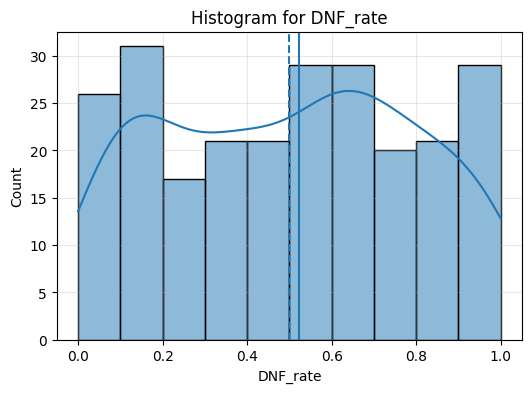

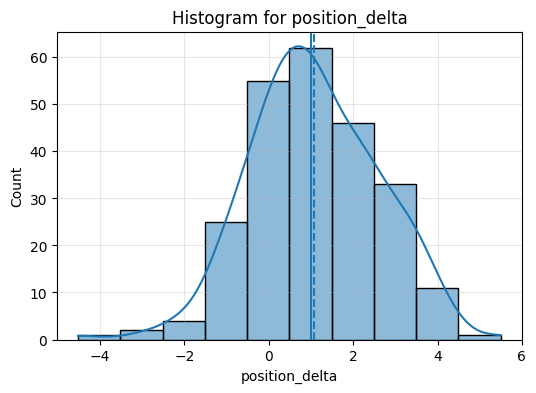

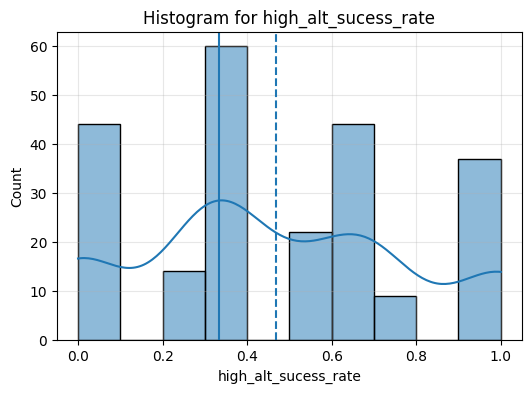

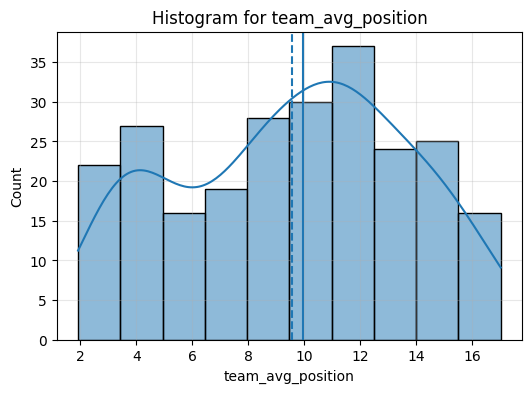

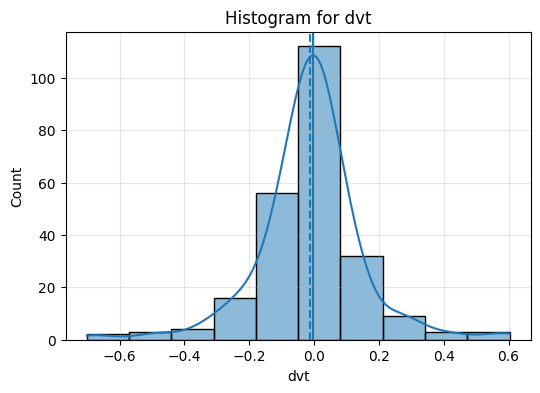

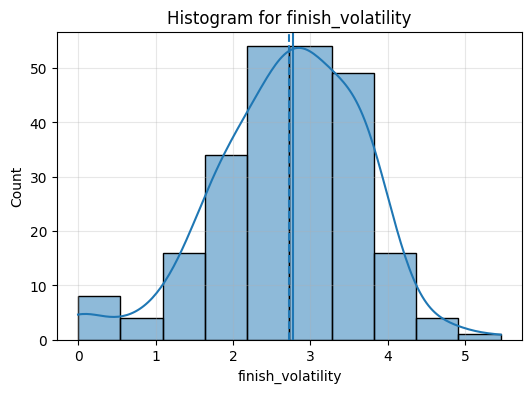

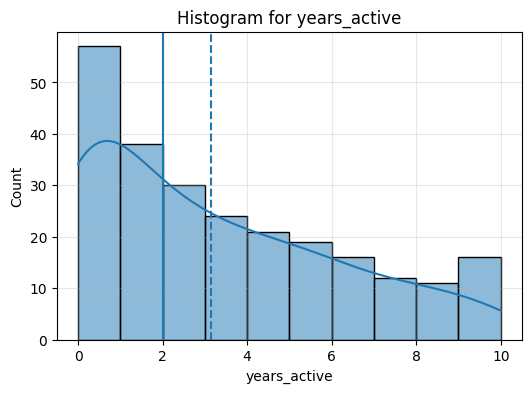

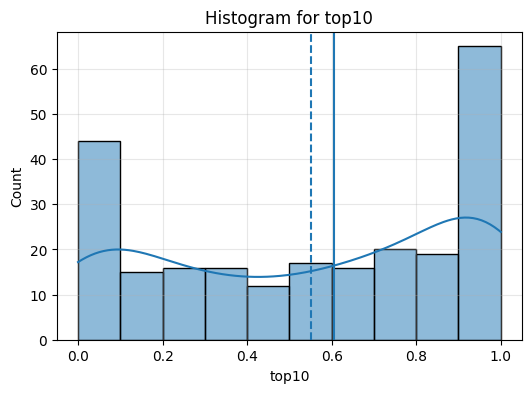

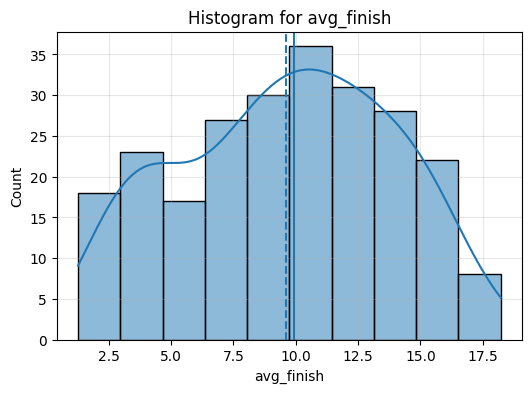

In [11]:
for var in features:
    plt.figure(figsize=(6,4))
    plt.axvline(df[var].mean(), linestyle="--", label=f"Mean: {df[var].mean():.2f}")
    plt.axvline(df[var].median(), linestyle="-", label=f"Median: {df[var].median():.2f}")
    plt.title(f"Histogram for {var}")
    plt.grid(True, alpha=0.3)
    sns.histplot(df, x=var, kde=True, bins=10)
    plt.savefig(f"images/{var}_histogram.png", bbox_inches="tight", dpi=150)
    plt.show()

- DNF rate: The DNF rate is spread evenly throughout the dataset, with no clear pattern visible. This variable is not normally distributed, and although there is no apparent skew, transformations might normalize its distribution for regression modeling.
- Position delta: Position delta has a clear pattern which is coherent with reality, most of the drivers finish in the same range of positions with some variation throughout a season, while other drivers are known for over/underperforming. It is important to note that drivers with a few races in a season can be outliers that skew this graph, due to the fact that their few races have a very high impact on this metric (EX: If a driver only had 3 races in a season, and his starting grid position differs significantly with their finish position, his position delta will be bigger in magnitude). The distribution of this variable is approximately normal which is great for regression modeling.
- High altitude success rate: There is no clear pattern and this variable is not  normally distributed as expected, transformations might be useful, nonetheless, a non linear model might be of help due to the fact that it will contextualize it. 
- Team avg position: This variable is roughly normally distributed, with the average falling around the middle of the grid. Something worth noting is the high count at the top 5, which is sensible given that the same dominant teams (e.g., Mercedes & Red Bull) have consistently occupied the top 5 positions from 2014 onwards.
- Dvt: This feature is normally distributed and it is coherent with reality given the definition of the variable in mind. Most pairs of drivers finish in the same range of positions and there are some clear over/underperformers in relation to their teammates, this is can be viewed in the almost symmetrical shape of the graph. EX(Verstappen and Ricciardo had very similar performances in 2016 , while Hamilton and Bottas in 2019 differed by a lot)
- Years active: This variable has a heavy skew to the right, as expected. All drivers have a year 0, and not all race for many years, which explains the distribution. On first glance this could be a concern, but the presence of other features will contextualize years active for the model. Non-linear models can also handle this pattern effectively, and transformations could further normalize its distribution.
- Top 10 rate: This variable is not normally distributed, which is coherent. Many drivers finish in the top 10 in all of their races during a season, while others rarely do, resulting in heavy counts in the tails. A transformation might be useful, though a non-linear model will naturally handle this pattern.
- Avg finish: This feature is approximately normally distributed. A large portion of drivers are capable of scoring points but not consistently reaching the top 10, resulting in a concentration in the middle of the grid. This is clearly visible in the histogram counts.

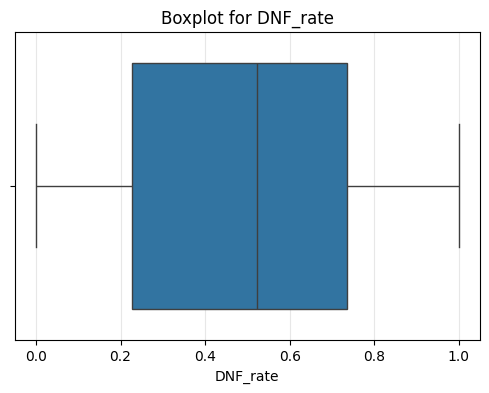

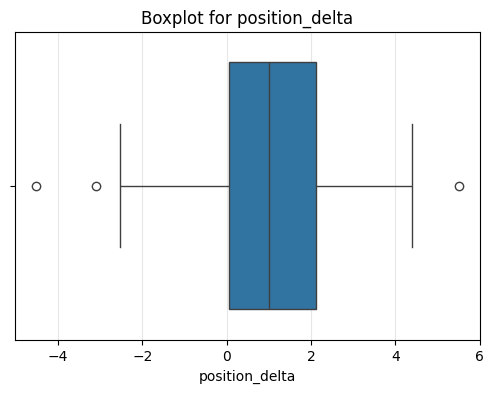

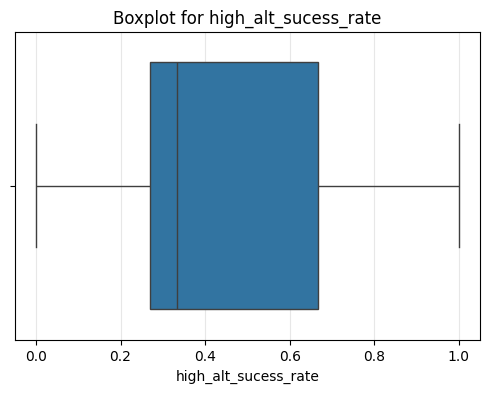

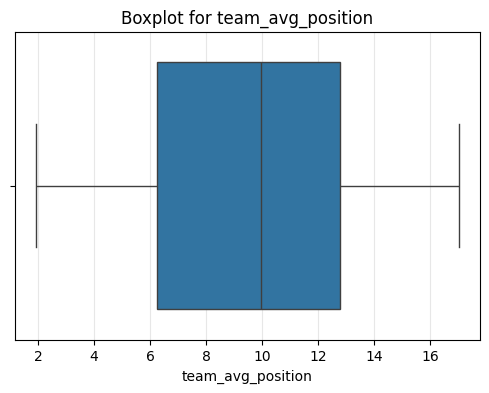

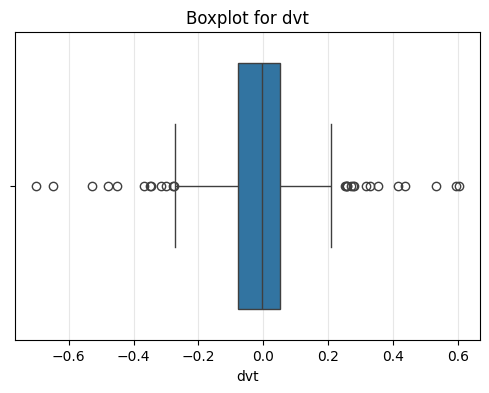

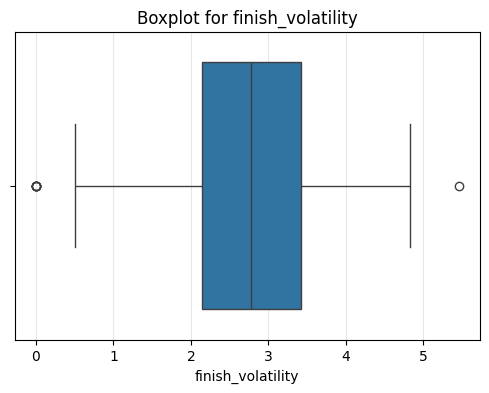

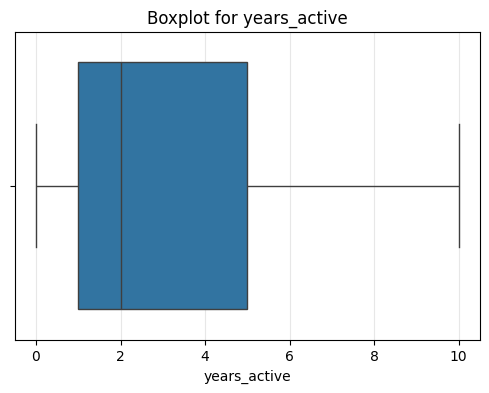

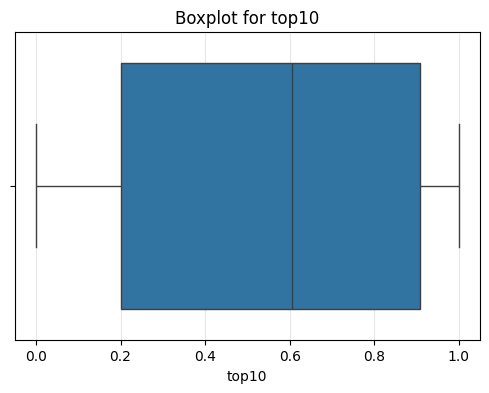

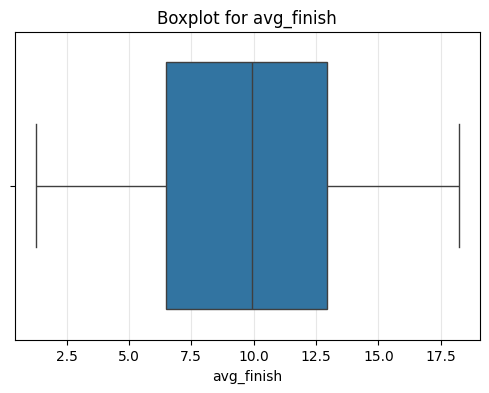

In [12]:
#Box plots
for var in features:
    plt.figure(figsize=(6,4))
    plt.title(f"Boxplot for {var}")
    plt.grid(True, alpha=0.3)
    sns.boxplot(df, x=df[var])
    plt.savefig(f"images/{var}_boxplot.png", bbox_inches="tight", dpi=150)
    plt.show()

- DNF Rate: The box plot for this feature confirms that there are no outliers present and that the data is spread widely relative to its range. DNF rate goes from 0 to 1, and the distance from IQ1 to IQ3 spans ~ 0.2 to ~ 0.7.
- Position delta: This box plot shows that most drivers have a finish delta of around the median ( ~0-2 positions), with a couple outliers present for over and under performers. 
- High altitude success rate: Similarly to dnf rate, there are no outliers present and this data is spread widely too in relation to its range, High altitude success rate goes from 0 to 1, and the distance from IQ1 to IQ3 spans ~ 0.3 to ~ 0.6. High-altitude races are few, so the rates are based on small denominators which makes this variable noisy.
- Team average position: As discussed before for driver average finish, most of the data is concentrated around the middle of the grid where the before mentioned drivers commonly finish, the same reasoning applies for both metrics, although drivers have more variance than teams in this aspect, their histogram and box plot are expected to look similar.
- Average finish: same as team average, is clustered between those middle grid positions, consistent with the roughly symmetric shape observed in the histogram.
- Dvt: We can see that most drivers are clustered in the middle range of the data  (~ -0.1 to 0.1), this is coherent with our histogram and the outliers in both tails represent the over and underperforming drivers. 
- Finish volatility: the box plot shows that most drivers have a low volatility in position terms (~ 2 - 3 positions), reaffirming the compactness of its distribution.
- Years active: the box plot highlights the skew of this variable as discussed before,  with most drivers in the 1 to 5 year range.
- Top 10: This box plot is spread very widely in relation to its range (0-1), IQ1 to IQ3 spans ~ 0.2 to ~ 0.9.


  
It is worth noting that due to the mathematical structure of the following variables (dnf rate, high altitude success rate, team average position, top 10 rate, average finish) it is unlikely to see any outliers. These variables have a lower and upper bound, which reduces extreme value magnitudes.


## Outlier analysis 

The nature of the outliers might be due to real noise in the data, or some driver's quality that is representative of their performance. The goal of this analysis is to comprehend the above mentioned fact and to manage this in a way that won't affect modeling.

### Position delta

In [13]:
df["position_delta"].describe()

count    240.000000
mean       1.081112
std        1.520530
min       -4.523810
25%        0.060033
50%        1.000000
75%        2.123950
max        5.500000
Name: position_delta, dtype: float64

In [14]:
position_delta_std = df["position_delta"].std()
position_delta_mean = df["position_delta"].mean()
#Define outlier thresholds
upper_threshold = position_delta_mean+2.0*position_delta_std
lower_threshold = position_delta_mean-2.0*position_delta_std

pd_outliers = []
for i in df["position_delta"]:
    if i >= upper_threshold or i <= lower_threshold:
        pd_outliers.append(i)
    else:
        pass
pd_outliers

[4.384615384615385,
 5.5,
 -2.526315789473685,
 -2.1999999999999993,
 -4.523809523809524,
 -2.0,
 -3.1111111111111107]

In [15]:
len(pd_outliers) / len(df["position_delta"]) 

0.028688524590163935

The outliers for position delta represent around 2% of the entire variable. Knowing this, we can look deeper into who these outliers are so that we can understand why their metric is extreme in relation to the mean.

In [16]:
mini_df = df[df["position_delta"].isin(pd_outliers)]
mini_df

,driverId,year,DNF_rate,ref,constructor,constructorRef,position_delta,high_alt_sucess_rate,team_avg_position,dvt,finish_volatility,years_active,top10,avg_finish
18,813,2014,0.789474,maldonado,208,lotus_f1,4.384615,1.000000,13.000000,-0.053254,2.333192,0,0.076923,13.692308
79,843,2017,1.000000,brendon_hartley,5,toro_rosso,5.500000,0.000000,11.131579,-0.257683,1.000000,0,0.000000,14.000000
102,825,2019,0.714286,kevin_magnussen,210,haas,-2.526316,0.333333,13.050000,-0.012301,3.621267,5,0.210526,13.210526
153,815,2021,0.227273,perez,9,red_bull,-2.200000,1.000000,4.545455,-0.452000,4.820788,7,0.800000,6.600000
195,807,2023,0.545455,hulkenberg,210,haas,-4.523810,0.500000,14.568182,0.019389,2.657296,9,0.047619,14.285714
217,848,2024,0.692308,albon,3,williams,-2.000000,0.000000,15.260870,0.135043,3.155947,5,0.200000,13.200000
241,825,2023,0.681818,kevin_magnussen,210,haas,-3.111111,0.250000,14.568182,-0.022014,2.922877,9,0.166667,14.888889


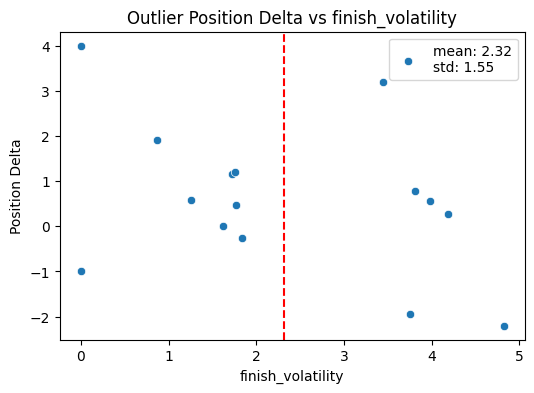

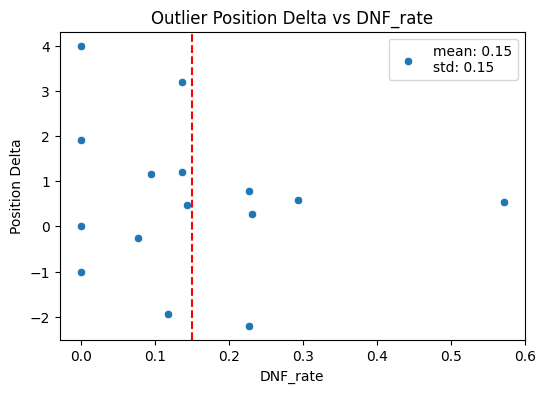

In [54]:
# Mini dataset of outliers
outliers = mini_df
for var in ["finish_volatility", "DNF_rate"]:
    plt.figure(figsize=(6,4))

    sns.scatterplot(x=var, y="position_delta", data=outliers)
    plt.axvline( outliers[var].mean(), color='red', linestyle='--', label=f'{var} mean: { outliers[var].mean():.2f}')
    plt.legend([f'mean: { outliers[var].mean():.2f}\nstd: { outliers[var].std():.2f}'])


    plt.xlabel(var)
    plt.ylabel("Position Delta")
    plt.title(f"Outlier Position Delta vs {var}")
    
    plt.savefig(f"images/{var}_outliers.png", bbox_inches="tight", dpi=150)
    plt.show()


A driver with a low finish volatility (less than 1 std away from mean) and a high position delta indicates a real overperformance, this is a driver who constantly improves his starting position, hence their low volatility. Conversely, a driver with a high finish volatility (more than 1std away form mean) and a high could indicate small sample effect, or that he is just a very inconsistent driver.  

As for DNF rate, we can see that at least half of the drivers with a high position delta have a high dnf rate, which is to be expected given the definition of position_delta, which is calculated for races where the driver FINISHED. With this in mind, we can infer that a driver with a low dnf rate (~ less than 1st away from mean) is a true over or under performer.

To discern whether or not the drivers with a high dnf rate are just noise, we have to look into how many races they raced. Arbitrarily defining it, A low amount of races in a season is  < 1/3 of races in a season.

If a driver races a low amount of races in a season, and their dnf rate is high, we can determine they're noise, if not, then it is a true signal of their performance.

In [55]:
driver_season = pd.read_csv("modeling_tables/driver_season.csv")

#Merge races_entered on dataframe by year and driverId
df = df.merge(
    driver_season[["driverId", "year", "races_entered"]],
    on=["driverId", "year"],
    how="left"
)

In [58]:
outliers = outliers.merge(
    driver_season[['driverId', 'year', 'races_entered']],
    on=['driverId','year'],
    how='left'
)

In [59]:
outliers.columns

Index(['driverId', 'year', 'DNF_rate', 'ref', 'constructor', 'constructorRef',
       'position_delta', 'high_alt_sucess_rate', 'team_avg_position', 'dvt',
       'finish_volatility', 'years_active', 'top10', 'avg_finish',
       'races_entered_x', 'max_races_in_season_x', 'season_fraction',
       'races_entered_y', 'max_races_in_season_y', 'races_entered'],
      dtype='str')

In [60]:
# Max races in each season
max_races_per_season = driver_season.groupby("year")["races_entered"].max().reset_index()
max_races_per_season = max_races_per_season.rename(columns={"races_entered": "max_races_in_season"})
outliers = outliers.merge(max_races_per_season, on="year", how="left")
outliers["season_fraction"] = outliers["races_entered"] / outliers["max_races_in_season"]

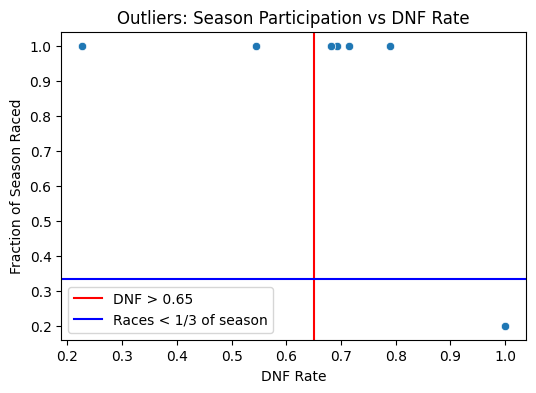

In [22]:
dnf_threshold = 0.65
season_fraction_threshold = 1/3  # low races fraction

plt.figure(figsize=(6,4))
sns.scatterplot(
    x="DNF_rate", 
    y="season_fraction", 
    data=outliers
)

plt.axvline(dnf_threshold, color='red', linestyle='-', label=f"DNF > {dnf_threshold:.2f}")
plt.axhline(season_fraction_threshold, color='blue', linestyle='-', label='Races < 1/3 of season')
plt.xlabel("DNF Rate")
plt.ylabel("Fraction of Season Raced")
plt.title("Outliers: Season Participation vs DNF Rate")
plt.legend()

plt.savefig(f"images/participation_outlier.png", bbox_inches="tight", dpi=150)
plt.show()

In [61]:
dnf_threshold = 0.65
race_fraction_threshold = 1/3
#High DNF + Low Season Participation - Noise
q_noise = outliers[
    (outliers["DNF_rate"] > dnf_threshold) &
    (outliers["season_fraction"] < race_fraction_threshold)
]
#High DNF + High Participation - True Underperformance Signal
q_high_dnf_full = outliers[
    (outliers["DNF_rate"] > dnf_threshold) &
    (outliers["season_fraction"] >= race_fraction_threshold)
]
#Low DNF + Low Participation - Small Sample (Uncertain Signal)
q_low_dnf_low_races = outliers[
    (outliers["DNF_rate"] <= dnf_threshold) &
    (outliers["season_fraction"] < race_fraction_threshold)
]
#Low DNF + High Participation - Strong Reliable Signal
q_reliable = outliers[
    (outliers["DNF_rate"] <= dnf_threshold) &
    (outliers["season_fraction"] >= race_fraction_threshold)
]

In [24]:
print("High DNF + Low Season Participation - Noise")
q_noise[["ref", "constructorRef", "position_delta", "DNF_rate", "races_entered", "year"]]

High DNF + Low Season Participation - Noise


,ref,constructorRef,position_delta,DNF_rate,races_entered,year
1,brendon_hartley,toro_rosso,5.5,1.0,4,2017


In [25]:
print("High DNF + High Season Participation -  True Underperformance Signal")
q_high_dnf_full[["ref", "constructorRef", "position_delta", "DNF_rate", "races_entered", "year"]]

High DNF + High Season Participation -  True Underperformance Signal


,ref,constructorRef,position_delta,DNF_rate,races_entered,year
0,maldonado,lotus_f1,4.384615,0.789474,19,2014
2,kevin_magnussen,haas,-2.526316,0.714286,21,2019
5,albon,williams,-2.000000,0.692308,13,2024
6,kevin_magnussen,haas,-3.111111,0.681818,22,2023


In [26]:
print("Low DNF + Low Participation - Small Sample (Uncertain Signal)")
q_low_dnf_low_races[["ref", "constructorRef", "position_delta", "DNF_rate", "races_entered", "year"]]

Low DNF + Low Participation - Small Sample (Uncertain Signal)


,ref,constructorRef,position_delta,DNF_rate,races_entered,year


In [27]:
print("Low DNF + High Participation - Strong Reliable Signal")
q_reliable[["ref", "constructorRef", "position_delta", "DNF_rate", "races_entered", "year"]]

Low DNF + High Participation - Strong Reliable Signal


,ref,constructorRef,position_delta,DNF_rate,races_entered,year
3,perez,red_bull,-2.20000,0.227273,22,2021
4,hulkenberg,haas,-4.52381,0.545455,22,2023


This graph is our key for understanding what is going on. The drivers with a high dnf rate and a low race season count are in the bottom right box, this is our noise as defined before. The drivers in the top right box are the drivers who raced more than 33% of the season yet have a high DNF rate, this is a clear signal of underperforming. The bottom left box drivers are those who raced only a few races yet finished in most of them, this is a signal of good performance. Where as drivers with low dnf rate and high amount of season races are signaling a true underperformance relative to their position delta.

Our DNF cutoff is set at 0.65, meaning that if a driver failed to finish more than 65% of their races in a season, we classify that season as high DNF. This gives us a clear and practical boundary between normal race attrition and seasons where reliability or incidents clearly dominated the results.

When we look at the tables, some cases match what we know from the sport. For example, Alonso in 2015 showing up in the high DNF high participation group makes sense because that McLaren season was extremely unreliable and full of retirements. Maldonado also appearing in the high DNF group is consistent with his known risk-heavy driving and incident record. On the other hand, drivers like Verstappen and Ricciardo appearing in the low DNF high participation group fits their reputation for consistency and strong race finishes over full seasons.

Drivers with very low season participation produce unstable rate-based features. To reduce variance and improve statistical reliability, drivers below 33% season participation were excluded from the modeling dataset.

In [62]:
season_race_counts = {
    2014: 19,
    2015: 19,
    2016: 21,
    2017: 20,
    2018: 21,
    2019: 21,
    2020: 17,
    2021: 22,
    2022: 22,
    2023: 22,
    2024: 13
}
df["max_races_in_season"] = df["year"].map(season_race_counts)
df["season_fraction"] = df["races_entered"] / df["max_races_in_season"]
df_clean = df.drop(q_noise.index).copy()

In [63]:
print(f"Original dataframe length: {len(df)}\nCleaned dataframe length: {len(df_clean)}\n# Of observations to be dropped: {len(q_noise)}")

Original dataframe length: 244
Cleaned dataframe length: 244
# Of observations to be dropped: 0


The observations dropped only represent about 0.04% of the dataset.

In [64]:
q_noise

,driverId,year,DNF_rate,ref,constructor,constructorRef,position_delta,high_alt_sucess_rate,team_avg_position,dvt,...,years_active,top10,avg_finish,races_entered_x,max_races_in_season_x,season_fraction,races_entered_y,max_races_in_season_y,races_entered,max_races_in_season


In [65]:
print("Cleaned position delta summary")
df_clean["position_delta"].describe()

Cleaned position delta summary


count    240.000000
mean       1.081112
std        1.520530
min       -4.523810
25%        0.060033
50%        1.000000
75%        2.123950
max        5.500000
Name: position_delta, dtype: float64

In [66]:
print("Position delta summary")
df["position_delta"].describe()

Position delta summary


count    240.000000
mean       1.081112
std        1.520530
min       -4.523810
25%        0.060033
50%        1.000000
75%        2.123950
max        5.500000
Name: position_delta, dtype: float64

Removing high-DNF low-participation driver-season records produced only minor shifts in the overall feature distributions, confirming that the dataset is robust while eliminating structurally unreliable samples that could distort rate-based metrics.

In [67]:
df = df_clean

### DVT

In [34]:
df["dvt"].describe()

count    239.000000
mean      -0.011238
std        0.163886
min       -0.700905
25%       -0.077469
50%       -0.002083
75%        0.052343
max        0.603060
Name: dvt, dtype: float64

DVT shows clear outliers on both tails of the distribution. Most drivers cluster tightly around zero, indicating performance close to their team baseline. The extreme values correspond to strong over- and under-performance seasons.

In [68]:
dvt_std = df["dvt"].std()
dvt_mean = df["dvt"].mean()

upper_threshold =dvt_mean+2.0*dvt_std
lower_threshold = dvt_mean-2.0*dvt_std

dvt_outliers = []
for i in df["dvt"]:
    if i >= upper_threshold or i <= lower_threshold:
        dvt_outliers.append(i)
    else:
        pass
len(dvt_outliers)

16

The outliers represent 6% of the total sample variable. Knowing this, we can look deeper into who these outliers are so that we can understand why their metric is extreme in relation to the mean.

In [69]:
mini_df = df[df["dvt"].isin(dvt_outliers)]
print(f"Outlier:\ndvt < {lower_threshold:.2f} (-34%)\ndvt > {upper_threshold:.2f} (32%)")
mini_df[["ref", "constructorRef", "dvt", "year"]]

Outlier:
dvt < -0.34 (-34%)
dvt > 0.32 (32%)


,ref,constructorRef,dvt,year
81,hamilton,mercedes,0.315789,2018
87,bottas,mercedes,-0.366574,2018
99,max_verstappen,red_bull,0.329840,2019
114,bottas,mercedes,-0.345183,2020
123,gasly,red_bull,-0.700905,2019
130,hamilton,mercedes,0.415138,2020
142,max_verstappen,red_bull,0.603060,2020
146,max_verstappen,red_bull,0.594737,2021
153,perez,red_bull,-0.452000,2021
169,bottas,mercedes,-0.349693,2021


In [70]:
# Keep only the noise rows
noise_conditions = (
    ((df["ref"] == "gasly") & (df["year"]==2019)) |
    ((df["ref"] == "de_vries") & (df["year"] == 2022)) |
    ((df["ref"] == "bearman") & (df["year"] == 2024))
)

noise_only = df[noise_conditions].copy()
noise_only

,driverId,year,DNF_rate,ref,constructor,constructorRef,position_delta,high_alt_sucess_rate,team_avg_position,dvt,finish_volatility,years_active,top10,avg_finish,races_entered,max_races_in_season,season_fraction
123,842,2019,0.571429,gasly,9,red_bull,0.55,0.666667,5.261905,-0.700905,3.980892,2,0.7,8.95,21,21,1.000000
234,856,2022,0.000000,de_vries,3,williams,-1.00,NaN,13.928571,0.353846,0.000000,0,1.0,9.00,1,22,0.045455
236,860,2024,0.000000,bearman,6,ferrari,4.00,NaN,4.583333,-0.527273,0.000000,0,1.0,7.00,1,13,0.076923


Post 2014 there has been 2 dominant teams, Mercedes and RedBull, with Hamilton and Verstappen as their main and most successful driver respectively. Knowing this information, the majority of these outliers make complete sense, and they are NOT noise by any means. Now, there are 3 drivers in here that do not fit that category. 

Nyck de vries raced only 1 time during the 2022 and Ollie bearman raced 3 times during the 2024 season. Logically we can argue that these observations are noisy and are not going to signal anything. As for Gasly further analysis is required. 

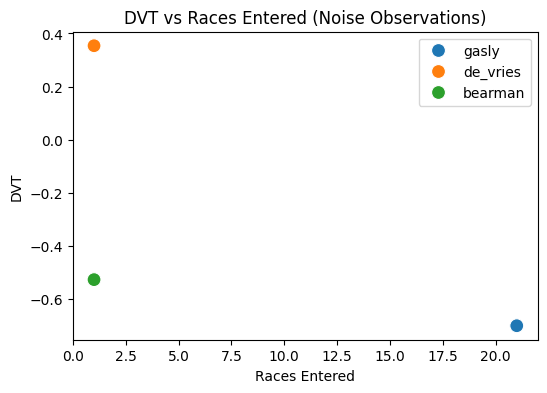

In [38]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    x="races_entered",
    y="dvt",
    data=noise_only,
    hue="ref",  
    s=100
)

mean_val = noise_only["races_entered"].mean()
std_val = noise_only["races_entered"].std()
plt.legend()

plt.xlabel("Races Entered")
plt.ylabel("DVT")
plt.title("DVT vs Races Entered (Noise Observations)")

plt.savefig(f"images/noise_observations.png", bbox_inches="tight", dpi=150)
plt.show()


Seeing this graph showcases the difference between noise and signals. Pierre Gasly had a terrible 2019 season which resulted in his -60% DVT, mean while the other two drivers have a super high and low DVT due to their limited races. Nyck de vries and Ollie Bearman will now be removed.

In [71]:
df_cleaned = df[~df['driverId'].isin([856, 860])].copy()

df_cleaned[df_cleaned['driverId'].isin([856, 860])]

,driverId,year,DNF_rate,ref,constructor,constructorRef,position_delta,high_alt_sucess_rate,team_avg_position,dvt,finish_volatility,years_active,top10,avg_finish,races_entered,max_races_in_season,season_fraction


In [72]:
print("Bearman and De Vries were succesfully removed")
df_cleaned['driverId'].unique()

Bearman and De Vries were succesfully removed


array([  3, 825,  18,   4, 822, 807,   8, 818, 826, 815, 821, 820, 828,
        20,   1, 817, 827,  16, 813, 155, 829,  13, 831, 832, 830, 834,
       837, 824, 835, 841, 840, 814, 843, 838, 844, 845, 846, 848, 847,
         9, 833, 836, 839, 842, 154, 849, 850, 854, 853, 851, 855, 857,
       858, 852, 859])

In our outlier analysis, we focused on identifying extreme observations in the DVT and related performance metrics. Initially, using standard deviation thresholds, we flagged several drivers with unusually high or low DVT values. Upon closer inspection, most of the extreme values corresponded to dominant drivers from Mercedes and Red Bull, such as Hamilton and Verstappen, which are valid signals rather than noise. However, a few observations stood out as true noise: Nyck de Vries (2022) and Ollie Bearman (2024), who had very limited race participation, and a poor 2019 season for Pierre Gasly. Given their minimal participation, De Vries and Bearman’s DVT values were inflated and unlikely to provide meaningful signal for modeling. We retained Gasly’s data for further analysis, as it reflected a legitimate underperformance in a full season. These noisy observations were removed from the dataset to ensure the model focuses on meaningful patterns, while signal-driven extremes from main drivers were preserved.

In [41]:
df.head()

,driverId,year,DNF_rate,ref,constructor,constructorRef,position_delta,high_alt_sucess_rate,team_avg_position,dvt,finish_volatility,years_active,top10,avg_finish,races_entered,max_races_in_season,season_fraction
0,3,2014,0.157895,rosberg,131,mercedes,-0.823529,1.0,1.921053,-0.316680,2.952918,0,0.941176,2.529412,19,19,1.0
2,18,2014,0.315789,button,1,mclaren,0.833333,0.5,8.710526,0.138973,3.670453,0,0.722222,7.500000,19,19,1.0
3,4,2014,0.105263,alonso,6,ferrari,1.176471,0.5,7.473684,0.275891,1.816876,0,1.000000,5.411765,19,19,1.0
4,822,2014,0.105263,bottas,3,williams,0.277778,0.5,6.157895,0.097816,2.650413,0,0.944444,5.555556,19,19,1.0
5,807,2014,0.210526,hulkenberg,10,force_india,3.235294,0.0,8.058824,0.043796,2.294872,0,0.882353,7.705882,19,19,1.0


## Bivariate analysis and collinearity

Moving on next it is important to understand how the features at hand correlate to our variable of interest (total points), and how they interact with each other. Understanding these relationships allows us to evaluate which features have strong linear associations with total points, which ones show weak or conditional effects, and which may only become informative when combined with other variables. Correlation analysis provides an initial signal of predictive strength and potential redundancy between features, while pairwise interaction analysis helps identify dependencies and context-driven behavior that simple univariate distributions cannot capture. Together, these checks guide both feature selection and model choice, especially when deciding between linear and non-linear modeling approaches.

In [73]:
df = df.merge(
    driver_season[["driverId", "year", "total_points"]],
    on=["driverId", "year"],
    how="left"
)

In [74]:
features["avg_finish"] = df["avg_finish"].reset_index(drop=True)

### Regression plots

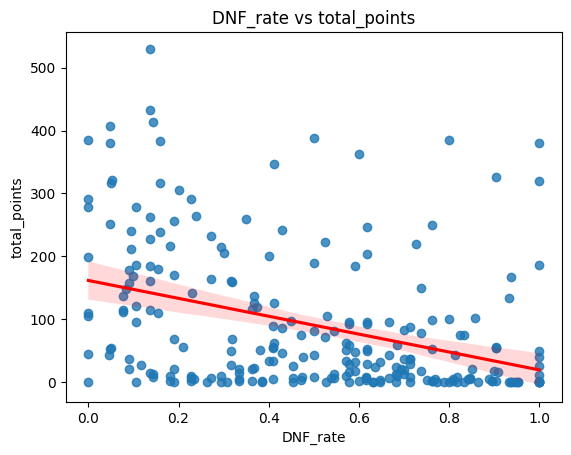

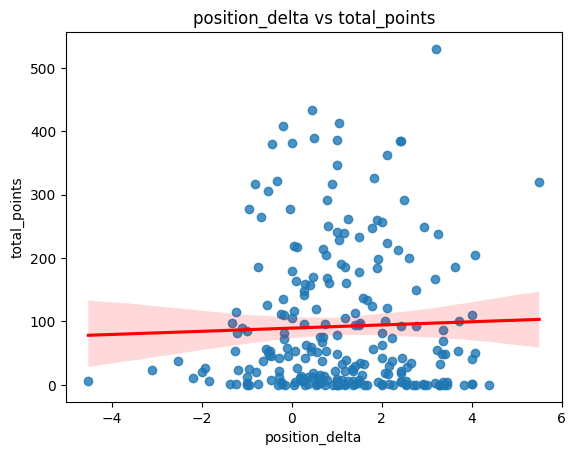

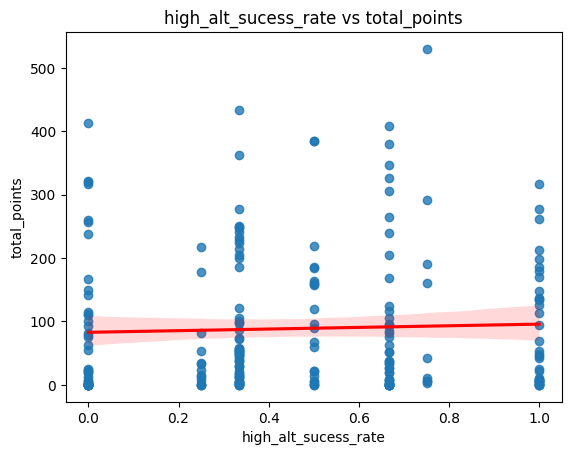

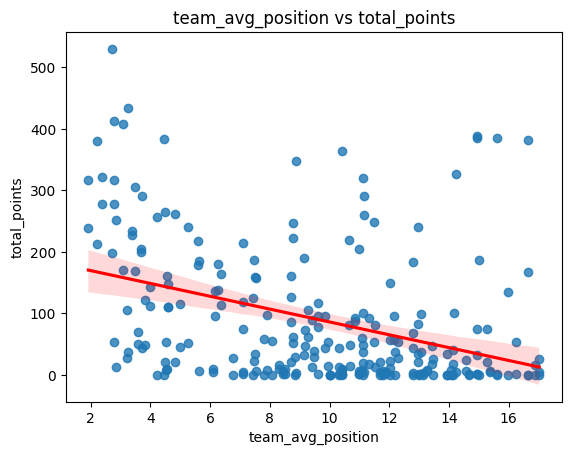

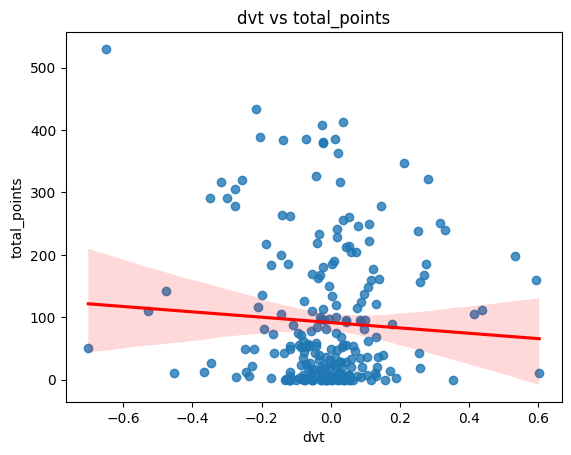

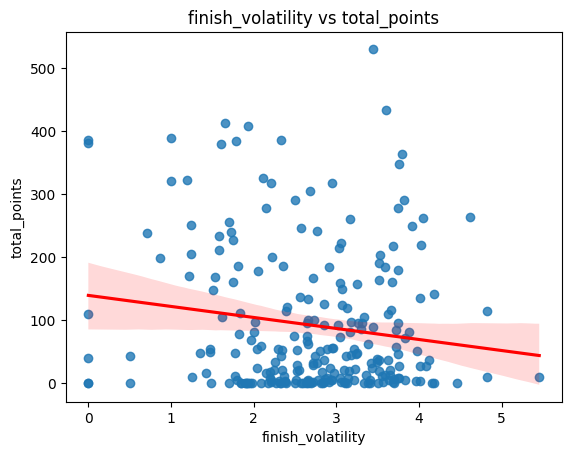

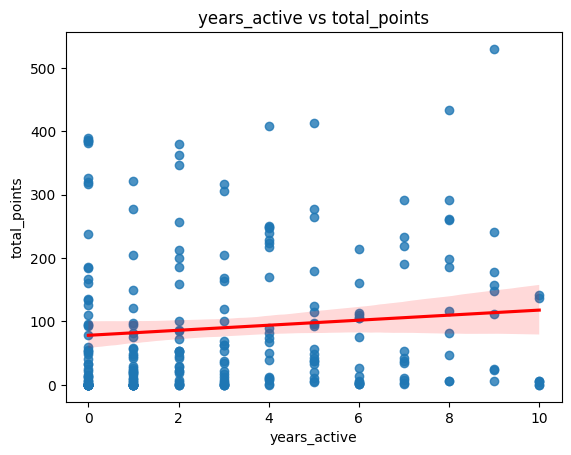

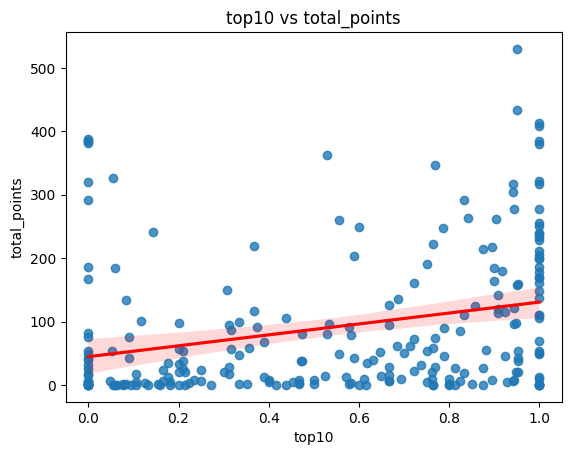

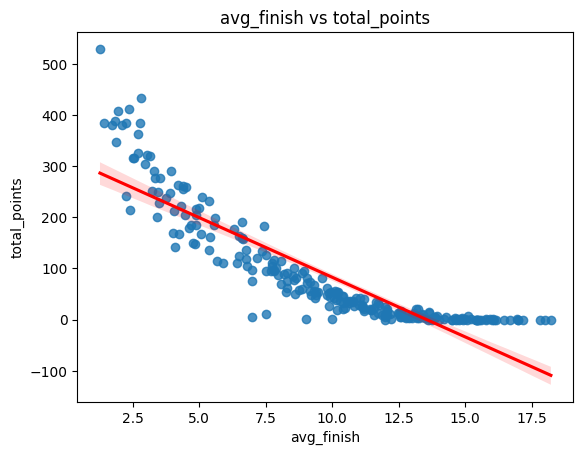

In [44]:
plot_df = features.reset_index(drop=True).join(
    df["total_points"].reset_index(drop=True)
)

for var in features.columns:
    if var == "year":
        pass
    else:
        plt.figure()
        sns.regplot(data=plot_df, x=var, y="total_points", line_kws={"color": "red"})
        plt.title(f"{var} vs total_points")
        plt.savefig(f"images/{var}_regression.png", bbox_inches="tight", dpi=150)
        plt.show()


- DNF rate has prominent negative correlation with total points, we can see that total points in a season heavily decrease with a curvature shape as dnf rate increases, most of the drivers with a high dnf rate (>= 65%) belong to the low scoring area. This relationship is non linear and shows a decay pattern.
- No clear pattern is visible between position delta and total points. The relationship appears weak and noisy. Transformations may help reveal hidden structure, but it is also possible this feature has limited predictive power.
- High-altitude success rate is bounded between 0 and 1 and takes discrete values (EX 0, 0.33, 0.5, 0.66, 1.0) due to the small number of high-altitude races per season. This creates vertical clusters in the scatterplot. The relationship with total points is very noisy, suggesting limited predictive power, though transformations could reveal subtle patterns.
- Similarly to DNF rate but stronger, Team average position has a clear negative relationship with total points in a season. The lower the team average finish is, the lower a driver scores with almost certainty, majority of the drivers with around 100 points (top 10 almost guaranteed) have a team average starting position of <=10. This relationship is non linear and shows a decay pattern.
- Dvt shows a somewhat linear relationship with total points having into consideration the visible spread of the data. Overall a higher dvt (>=.3) yields a higher total point, and a lower dvt (<= -.3) yields a lower point score. Majority of drivers fall in the (-.2 to .2) range, dvt measures deviation from teammate, therefore most drivers are clustered near 0 because teammates often finish close to each other. Nonetheless this variable might have some explanatory power, and a transformation might reveal something else about its structure.
- Finish volatility shows no clear pattern whatsoever, some drivers with high/low volatility are high scorers and some others are low scorers. Most drivers cluster within (2-4) positions. This suggests limited predictive power, though transformations might highlight subtle effects.
- There is no clear linear relationship between years active and total points. Drivers with fewer years are scattered across the points range, although drivers with over 8 years of experience do not score past the 300 point mark. This feature may be more informative in interaction with other features rather than alone.
- For Top 10 rate There is a strong positive relationship with total points, as expected. Drivers with a higher top 10 finish rate tend to accumulate more points. The plot shows a steady upward increase, although the relationship flattens near the extremes due to bounded values.
- As expected, there is a negative relationship with total points and average finish. Lower average finish positions correspond to more points. The relationship is non linear and could benefit from a log or inverse transformation if needed for modeling.


### Correlations

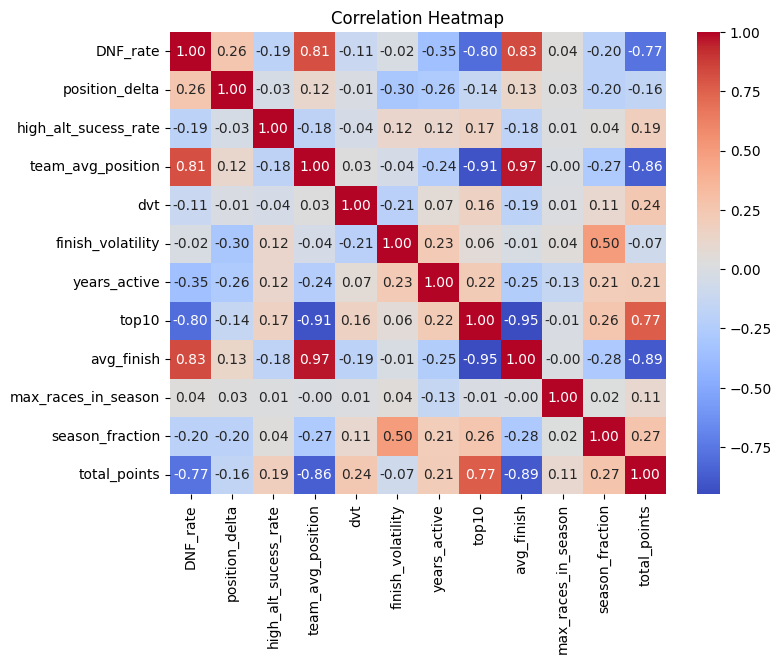

In [45]:
# Correlation function only takes numeric columns
numeric_df = df.drop(columns=["year", "driverId", "constructor", "races_entered"]).select_dtypes(include="number")

corr_matrix = numeric_df.corr()  

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")

plt.savefig(f"images/features_heatmap.png", bbox_inches="tight", dpi=150)
plt.show()

Focusing on the outcome variable total_points, several strong relationships appear that are consistent with both the scatter plot analysis and domain expectations. DNF rate shows a strong negative correlation (−0.79), indicating that drivers who fail to finish more frequently tend to accumulate fewer points. Similarly, average finish and team average position exhibit very strong negative correlations (−0.89 and −0.87), confirming that worse finishing positions are associated with lower season point totals. In contrast, top-10 rate shows a strong positive correlation (0.78), which is expected since frequent top-10 finishes directly contribute to higher points.

These results indicate that season outcome summary metrics are the dominant predictors of total points. However, these variables are also highly correlated with each other. Average finish, team average position, top-10 rate, and DNF rate form a tightly correlated cluster, reflecting that they measure closely related aspects of performance. Because of this, they should not be used together in the same linear model without regularization, and feature selection within this group will be necessary.

Outside of this performance cluster, most remaining engineered features show weak correlations, generally below |0.40|, suggesting limited multicollinearity among the secondary predictors. These variables may still contribute incremental predictive value when combined in multivariate models, particularly non-linear ones.

Because the Formula 1 scoring system is directly determined by finishing position, summary performance metrics such as average finish and top-10 rate naturally show very strong correlations with total points. Rather than treating this as a modeling flaw or leakage, this analysis treats these relationships as structural properties of the domain. The objective is therefore not to avoid these variables, but to use them as anchors while examining which additional performance dimensions help explain remaining variance in total points. In particular, factors such as reliability, race craft, constructor context, and performance consistency are evaluated for their independent and interaction effects on scoring outcomes.

While some individual performance-oriented metrics appear weakly correlated with total points when evaluated in isolation, this does not imply low explanatory value. Many of these variables are not expected to have strong marginal correlations by themselves; their contribution is conditional and interaction-driven. When considered jointly, they provide complementary information that helps explain variability in point scoring beyond what summary finish metrics alone capture.

In [46]:
features.columns

Index(['DNF_rate', 'position_delta', 'high_alt_sucess_rate',
       'team_avg_position', 'dvt', 'finish_volatility', 'years_active',
       'top10', 'avg_finish'],
      dtype='str')

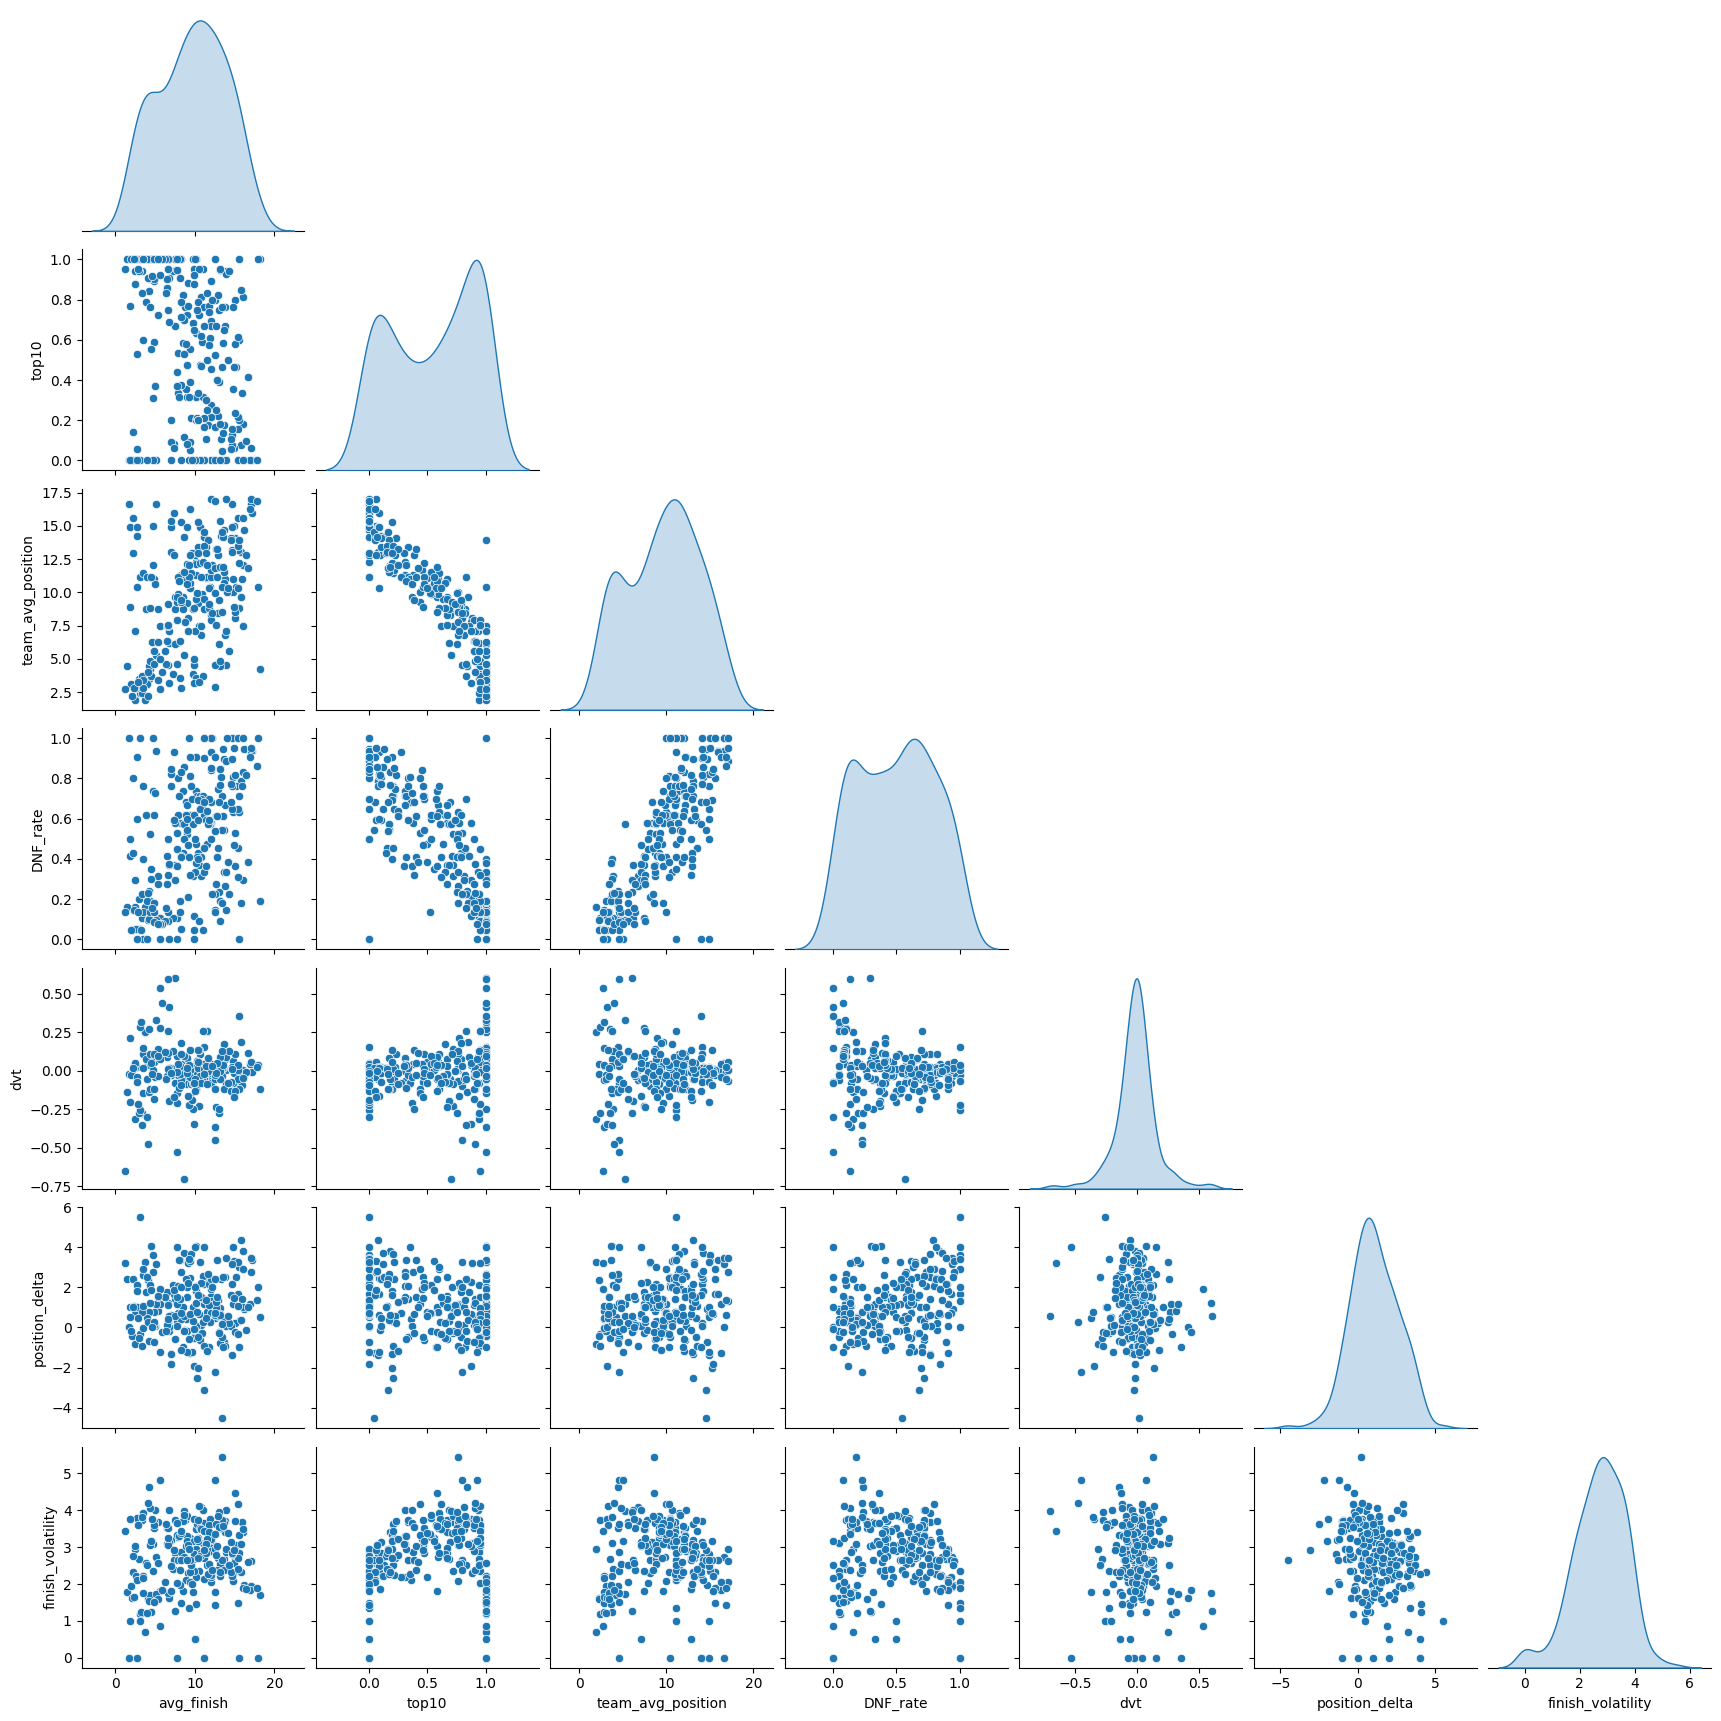

In [47]:
perf_features = [
    'avg_finish', 'top10', 'team_avg_position', 'DNF_rate',  'dvt', 'position_delta', 'finish_volatility'
]


context_features = [
    'years_active', 'high_alt_sucess_rate'
]

for cols in [perf_features, context_features]:
    sns.pairplot(
        features[cols],
        corner=True,         
        diag_kind="kde",     
    )
    plt.savefig(f"images/pairplots2.png", bbox_inches="tight", dpi=150)

    plt.show()

The performance summary variables with strong negative correlations exhibit clear linear relationships with each other, consistent with their Pearson correlation coefficients. Finish volatility, however, displays a prominent inverted-U (n-shaped) pattern when paired with average finish (-0.02), top-10 rate (-0.09), and team average finish (-0.04). While these correlations are weak, the pairwise scatterplots reveal meaningful structure: drivers with low finish volatility cluster near the top and bottom of the finishing order, while mid-pack drivers tend to have higher volatility. In the case of top-10 rate, most drivers occupy a similar volatility range, but a few drivers at both extremes of the performance spectrum maintain low volatility, indicating a weaker conditional effect compared to the other two relationships.

DVT and DNF rate exhibit a slight funnel-shaped pattern, with the spread narrowing for DNF rates above 0.30. DVT and position delta show no discernible pattern. Conversely, DNF rate and position delta show a positive linear trend, albeit with moderate scatter, suggesting a potential interaction effect between a driver’s reliability and their race-to-race positional changes.

Finally, years active and high-altitude success rate show a noisy relationship, likely influenced by missing values in the high-altitude success metric, which limits interpretability.

## Interaction analysis

The next stage of the analysis focuses on detecting interaction effects between predictors by examining how total points change across conditional levels of key performance variables. While earlier steps evaluated pairwise relationships and individual correlations with the target, many motorsport performance factors are not expected to act independently. Reliability, consistency, race craft, and team context often influence outcomes jointly rather than additively. To account for this, the analysis now evaluates how the relationship between one feature and total points varies when another feature is held at different levels. By stratifying predictors and comparing conditional target behavior, this step aims to identify non-additive structure and guide the inclusion of interaction terms and nonlinear specifications in the modeling phase.

Pairwise predictor analysis reveals a consistent curved relationship between finish volatility and multiple performance summary metrics, indicating that volatility behaves differently across performance tiers. This structure motivates testing interaction terms between finish volatility and performance variables. Additional moderate structure is observed between DNF rate and position delta, suggesting a secondary interaction candidate, while DVT shows largely patternless relationships and is therefore a lower interaction priority.

Finish volatility is therefore a primary interaction candidate, as evidenced by the curved structures observed in the pairplots. The following interactions will be tested:
- finish_volatility × avg_finish
- finish_volatility × top10
- finish_volatility × team_avg_position

DNF rate is also considered an interaction candidate. Many of the engineered performance features were computed excluding DNF outcomes, which helps explain the structured but nonlinear shapes observed in their pairwise plots with DNF rate. This supports testing interactions where reliability modifies the effect of performance and consistency metrics:
- DNF_rate × finish_volatility 
- DNF_rate × dvt

### Stratified scatter plots
Interactions will be evaluated by examining how the fitted relationship between a predictor and total points changes across stratified levels of a second predictor. If the fitted slopes differ meaningfully across these levels, this will be treated as evidence of a potential interaction effect; if slopes remain stable, an interaction term will not be pursued.
### Finish volatility

In [47]:
df[["finish_volatility"]].describe()

,finish_volatility
count,239.000000
mean,2.717374
std,0.951330
min,0.000000
25%,2.146358
50%,2.770103
75%,3.429536
max,5.456071


Finish volatility will be stratified into three balanced groups using quantile-based binning (low, medium, high). Although the variable is approximately normally distributed, this type of binning ensures more stable fitted slopes and more reliable visual comparison when evaluating interaction effects across strata.

In [76]:
fv_terciles = pd.qcut(df["finish_volatility"], q=3, labels=["Low", "Medium", "High"])
print(f"Sample:\n{fv_terciles.head()}\n\nCounts:\n{fv_terciles.value_counts().sort_index()}")

Sample:
0    Medium
1    Medium
2      High
3       Low
4    Medium
Name: finish_volatility, dtype: category
Categories (3, str): ['Low' < 'Medium' < 'High']

Counts:
finish_volatility
Low       80
Medium    80
High      80
Name: count, dtype: int64


In [77]:
df["fv_terciles"] = fv_terciles

In [78]:
df.head()

,driverId,year,DNF_rate,ref,constructor,constructorRef,position_delta,high_alt_sucess_rate,team_avg_position,dvt,finish_volatility,years_active,top10,avg_finish,races_entered,max_races_in_season,season_fraction,total_points,fv_terciles
0,3,2014,0.157895,rosberg,131,mercedes,-0.823529,1.0,1.921053,-0.316680,2.952918,0,0.941176,2.529412,19,19,1.0,317.0,Medium
1,825,2014,0.368421,kevin_magnussen,1,mclaren,-0.555556,1.0,8.710526,-0.077878,2.850709,0,0.666667,9.388889,19,19,1.0,55.0,Medium
2,18,2014,0.315789,button,1,mclaren,0.833333,0.5,8.710526,0.138973,3.670453,0,0.722222,7.500000,19,19,1.0,126.0,High
3,4,2014,0.105263,alonso,6,ferrari,1.176471,0.5,7.473684,0.275891,1.816876,0,1.000000,5.411765,19,19,1.0,161.0,Low
4,822,2014,0.105263,bottas,3,williams,0.277778,0.5,6.157895,0.097816,2.650413,0,0.944444,5.555556,19,19,1.0,186.0,Medium


### Average finish and points by finish volatility terciles

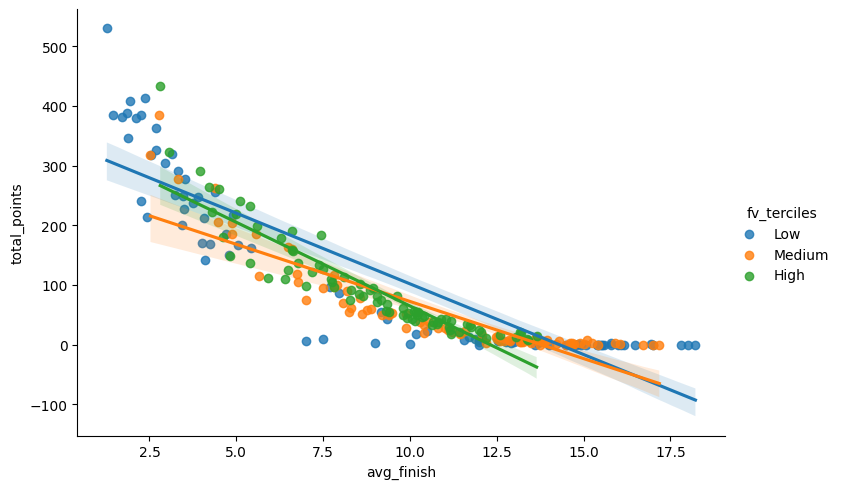

In [83]:
sns.lmplot(
    data=df,
    x="avg_finish",
    y="total_points",
    hue="fv_terciles",
    height=5,
    aspect=1.5,
) 
sns.relplot(
    data=df,
    x="avg_finish",
    y="total_points",
    col="fv_terciles",
    aspect=1.5,
)
sns.lmplot(
    data=df,
    x="avg_finish",
    y="total_points",
    hue="fv_terciles",   # "low", "medium", "high"
    lowess=True,          # smooth nonlinear trend
    height=5,
    aspect=1.5,
)



Since the relationship between the predictor and total points is visibly nonlinear,  interaction assessment is heavily based on the lowess curve. The relationship between average finish and total points is consistently negative across all finish volatility groups. However, slope differences are observed, with low-volatility drivers showing a steeper decline in total points as average finish worsens. Looking at the lowess curve the main difference is at the beginning of these lines, for which the lower and higher tercile drops more steeply, whereas the medium tercile is more gentle, although this difference is not very significant, it makes sense given the pairplot of these two variables that we saw before. This suggests a moderate interaction effect, where finish volatility slightly modifies the strength of the relationship between average finish and total points, although the overall direction remains stable.

It is also worth noting that drivers with real low volatility score a lot more points than those with high medium and volatility, which is sensical and can be seen by the big chunk of drivers with low average finish and high total points in the plot above, this chunk is not visible for the other two terciles

### Top 10 rate and total points by finish volatility terciles

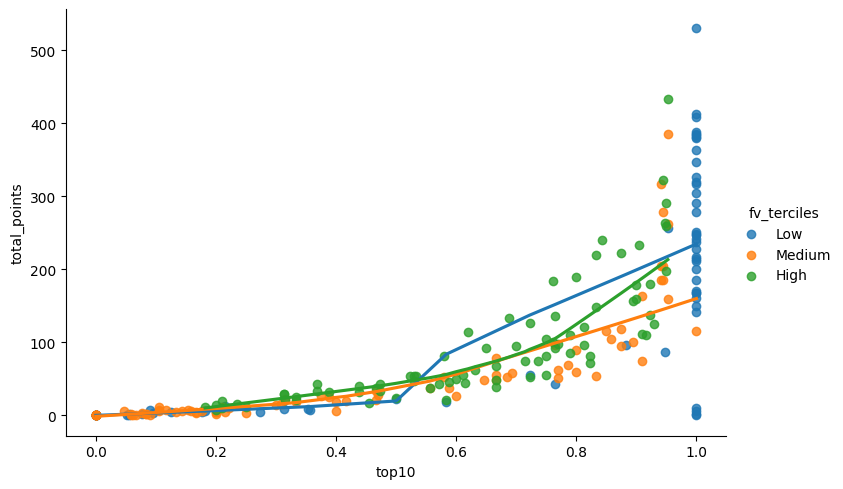

In [87]:
sns.lmplot(
    data=df,
    x="top10",
    y="total_points",
    hue="fv_terciles",
    height=5,
    aspect=1.5,
) 
sns.relplot(
    data=df,
    x="top10",
    y="total_points",
    col="fv_terciles",
    aspect=1.5,
)
sns.lmplot(
    data=df,
    x="top10",
    y="total_points",
    hue="fv_terciles",   # "low", "medium", "high"
    lowess=True,          # smooth nonlinear trend
    height=5,
    aspect=1.5,
)
# plt.savefig(f"images/lowess_top10_fv.png", dpi=150, bbox_inches="tight")

In this case it the difference between the difference terciles is bigger, yet is not very strong. Both have the same direction and a similar maginuted up a point where the three terciles of drivers intersect, (around 50% top 10 rate), after that point, we can see that low finish volatilty drivers shoot up drastically, this is most likely all those elite drivers that always score points, as shown by the vertical like at 100% top 10 rate, there is a pair of drivers with 100% top 10 rate and a very low point count, these are most likely drivers that finished near the 8-10 position range, where very low  points are awarded. As for the other two terciles (Medium and High), they are pretty much parallel up to a separation point (around 70% top 10 rate), where drivers with a higher volatiluty score more points, these are probably drivers who have a couple races where they scored very high hence their total point score went up. Overall there is a moderate interaction between top 10 rate and finish volatility, this interaction is specially important for drivers with low volatility and high total points scored in a season.

### Team average position and total points by finish volatility terciles

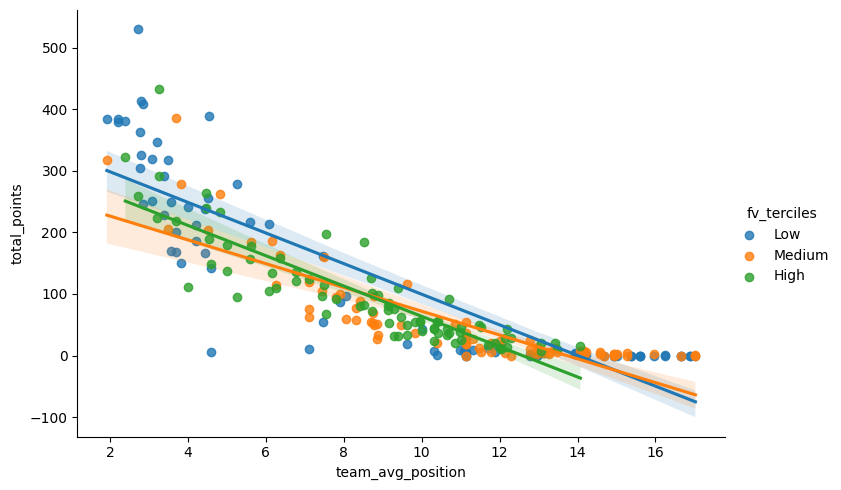

In [90]:
sns.lmplot(
    data=df,
    x="team_avg_position",
    y="total_points",
    hue="fv_terciles",
    height=5,
    aspect=1.5,
) 
sns.relplot(
    data=df,
    x="team_avg_position",
    y="total_points",
    col="fv_terciles",
    aspect=1.5,
)
sns.lmplot(
    data=df,
    x="team_avg_position",
    y="total_points",
    hue="fv_terciles",   # "low", "medium", "high"
    lowess=True,          # smooth nonlinear trend
    height=5,
    aspect=1.5,
)

# plt.savefig(f"images/stratified_team_fv.png", dpi=150, bbox_inches="tight")

The magnitude and slope of these lines are very similar, these lines are also parallel for the most part. It is overall very similar to the driver average finish plots, with a more pronounced slope for both low and high finish volatility drivers, with the main differnece being at the starting point, and then they get more tighter. There could be a moderate interaction effect.

Out of the three plots, I believe that the main interaction is for top 10 rate, where is more evident and different between the terciles.

### DNF Rate
### Total points vs DNF Rate by volatility terciles

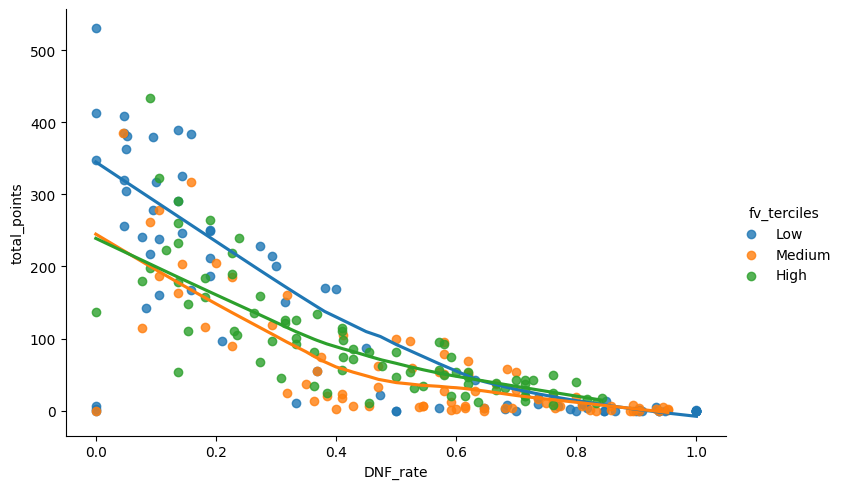

In [93]:
sns.lmplot(
    data=df,
    x="DNF_rate",
    y="total_points",
    hue="fv_terciles",
    height=5,
    aspect=1.5,
) 

sns.relplot(
    data=df,
    x="DNF_rate",
    y="total_points",
    col="fv_terciles",
    aspect=1.5,
)
sns.lmplot(
    data=df,
    x="DNF_rate",
    y="total_points",
    hue="fv_terciles",   # "low", "medium", "high"
    lowess=True,          # smooth nonlinear trend
    height=5,
    aspect=1.5,
)
plt.savefig(f"images/lowess_dnf_fv.png", dpi=150, bbox_inches="tight")

Across volatility terciles, the negative relationship between DNF rate and total points is again consistent in direction, but the differences between groups are more noticeable. At low DNF rates, drivers across all volatility levels score similarly high points. As DNF rate increases, the curves begin to separate.

Low-volatility drivers appear more sensitive to DNFs, with a steeper decline in total points. In contrast, medium and high volatility drivers show a slightly more gradual reduction, suggesting that occasional strong performances may partially offset missed races. Overall, this reflects a moderate interaction, where volatility influences how strongly DNFs affect seasonal point totals.

### Total points vs DNF Rate by DVT terciles

In [94]:
import pandas as pd

df['dvt_terciles'] = pd.qcut(
    df['dvt'],
    q=3,
    labels=['low', 'medium', 'high']
)


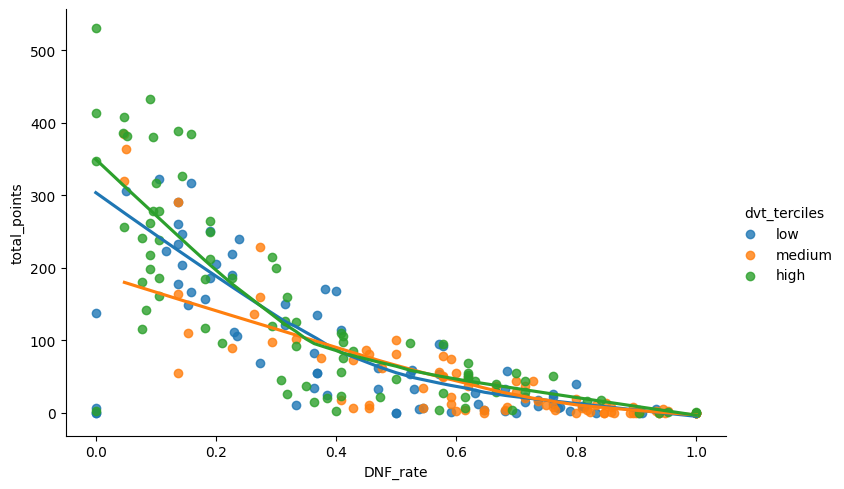

In [98]:
sns.lmplot(
    data=df,
    x="DNF_rate",
    y="total_points",
    hue="dvt_terciles",
    height=5,
    aspect=1.5,
) 

sns.relplot(
    data=df,
    x="DNF_rate",
    y="total_points",
    col="dvt_terciles",
    aspect=1.5,
)
sns.lmplot(
    data=df,
    x="DNF_rate",
    y="total_points",
    hue="dvt_terciles",   # "low", "medium", "high"
    lowess=True,          # smooth nonlinear trend
    height=5,
    aspect=1.5,
)
plt.savefig(f"images/lowess_dnf_dvt.png", dpi=150, bbox_inches="tight")

The differences between the DVT terciles are visible but not particularly strong. All three groups show the same overall pattern: as DNF rate increases, total points decrease. The direction of the relationship is consistent across terciles, and the slopes are fairly similar through much of the distribution. This suggests that DNFs negatively impact drivers regardless of their DVT level.

However, some separation appears at moderate DNF rates. Drivers in the high DVT tercile tend to lose points slightly more sharply as DNFs increase, while the medium and high DVT groups decline more gradually. The initial gap between low and medium-high dvt drivers is big (~ 100 points), which indicates that this effect is specially significant for low dnf rate drivers. Overall there is a modest interaction: although the overall effect of DNFs is negative for everyone, its magnitude varies somewhat depending on DVT.

### Interaction analysis using regression
To formally quantify the interaction between Top 1 rate and finish volatility on total points, I conducted an interaction analysis using regression modeling. While exploratory plots and LOWESS curves suggested that the effect of Top 10 rate on total points may vary across different levels of finish volatility, a regression model with an interaction term allows us to test this relationship statistically. By including both the main effects and the interaction between Top 1 rate and finish volatility (or terciles of volatility), we can assess whether the slopes differ significantly across volatility levels and provide a numerical estimate of the interaction magnitude.

Interactions tested:
- finish_volatility × avg_finish
- finish_volatility × top10
- finish_volatility × team_avg_position
- DNF_rate × finish_volatility
- DNF_rate × dvt

In [96]:
import statsmodels.formula.api as smf

predictors = ["avg_finish", "top10", "team_avg_position", "DNF_rate", "dvt"]

for var in predictors:
    # dvt interacts with DNF_rate, not finish_volatility
    if var == "dvt":
        formula = f"total_points ~ {var} * DNF_rate"
    else:
        formula = f"total_points ~ {var} * finish_volatility"
    
    print(f"Running model for interaction: {formula}")
    model = smf.ols(formula=formula, data=df).fit()
    
    # Name of the interaction term
    interaction_term = model.params.index[-1]
    
    # Interacation coefficient and p-value
    coef = model.params[interaction_term]
    pval = model.pvalues[interaction_term]
    
    print(f"Interaction term: {interaction_term}")
    print(f"Coef: {coef:.4f}, P-value: {pval:.4f}\n")


Running model for interaction: total_points ~ avg_finish * finish_volatility
Interaction term: avg_finish:finish_volatility
Coef: -0.7292, P-value: 0.4020

Running model for interaction: total_points ~ top10 * finish_volatility
Interaction term: top10:finish_volatility
Coef: 18.1719, P-value: 0.1883

Running model for interaction: total_points ~ team_avg_position * finish_volatility
Interaction term: team_avg_position:finish_volatility
Coef: 0.5438, P-value: 0.5566

Running model for interaction: total_points ~ DNF_rate * finish_volatility
Interaction term: DNF_rate:finish_volatility
Coef: -18.2316, P-value: 0.2366

Running model for interaction: total_points ~ dvt * DNF_rate
Interaction term: dvt:DNF_rate
Coef: -379.0188, P-value: 0.0009



The regression analysis of interactions shows that finish volatility does not significantly modify the effect of average finish, top 10 rate, or team average position on total points. In other words, being more or less consistent across races does not substantially change how these performance metrics contribute to a driver’s point total. By contrast, the interaction DVT × DNF rate is statistically significant, indicating that a driver’s relative performance compared to their teammates (DVT) interacts with reliability. Drivers who outperform their teammates more strongly (high DVT) experience a larger loss in total points when they have DNFs, while drivers closer to or below their teammates’ performance (low DVT) are less affected. This highlights that exceptional drivers are particularly penalized by missed finishes, emphasizing that both skill relative to the team and race reliability are crucial for maximizing total points across a season. 

These findings emphasize that explicit interaction terms are most meaningful in linear frameworks, allowing us to quantify how the effect of one variable depends on another. In this case, the significant DVT × DNF rate interaction highlights a conditional relationship that can be leveraged for predictive modeling and interpretation. For models that capture nonlinearity and splits automatically, such as tree-based approaches, this step is less critical, but in linear or regularized regression, testing interactions provides a clear, interpretable measure of how combined features influence total points.

In [149]:
df.columns

Index(['driverId', 'year', 'DNF_rate', 'ref', 'constructor', 'constructorRef',
       'position_delta', 'high_alt_sucess_rate', 'team_avg_position', 'dvt',
       'finish_volatility', 'years_active', 'top10', 'avg_finish',
       'races_entered', 'max_races_in_season', 'season_fraction',
       'total_points', 'fv_terciles', 'dvt_terciles'],
      dtype='str')

## Transformations

Logit and arcsine transformations were applied to the dataset to improve the statistical properties of the variables and ensure comparability across features. Many of the performance metrics are expressed as rates or proportions, which can be highly skewed or bounded between 0 and 1. To address this, selected variables such as DNF rate and top-10 finish rate were transformed using the logit function, allowing extreme probabilities to be represented more symmetrically and improving their suitability for subsequent analysis. Additionally, all continuous variables were standardized so that each feature contributes equally to the analysis, preventing variables with larger scales from dominating the results. These transformations create a more stable and interpretable feature space, preparing the data for principal component analysis and the clustering procedures that follow.

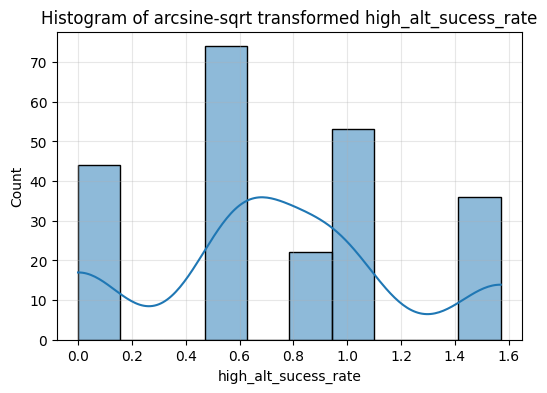

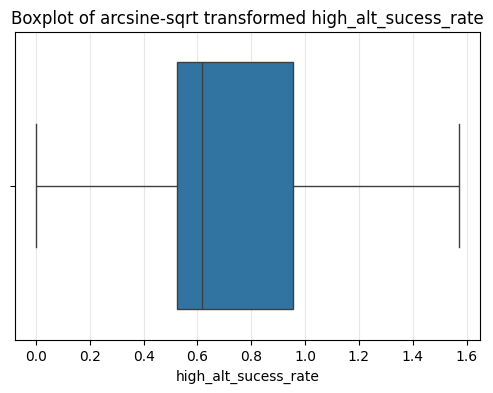

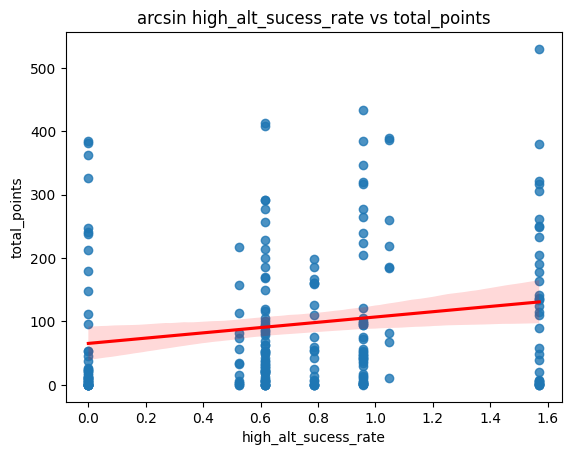

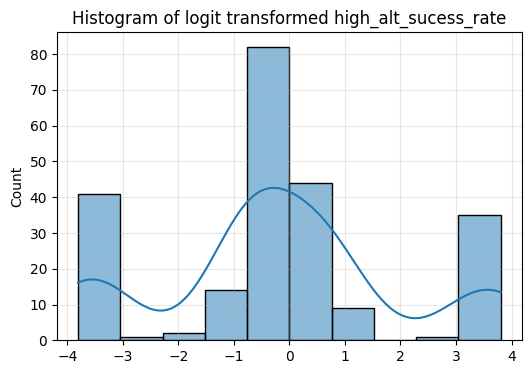

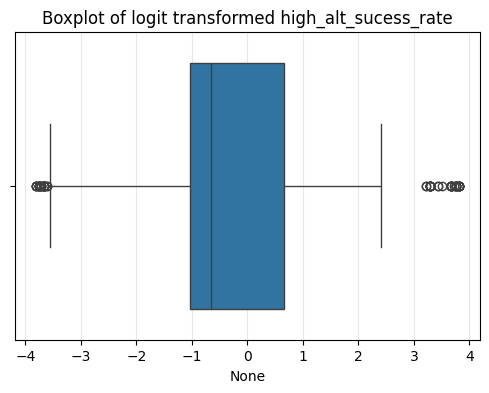

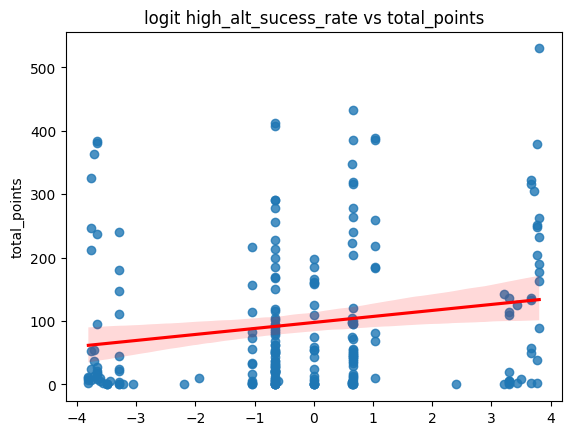

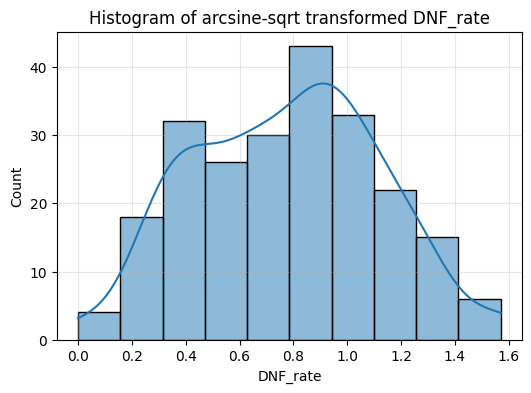

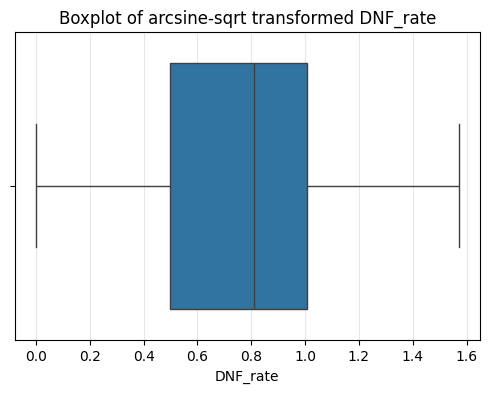

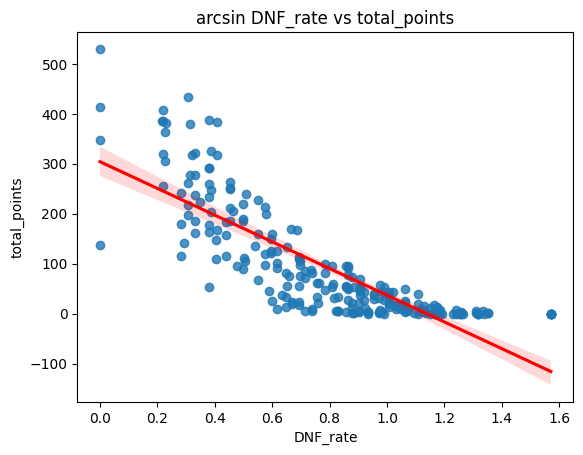

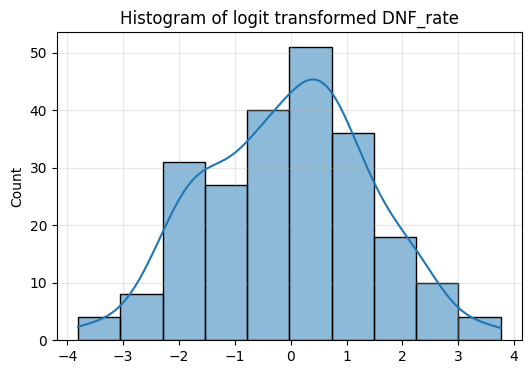

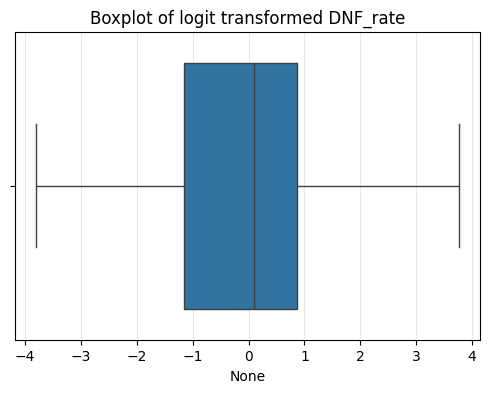

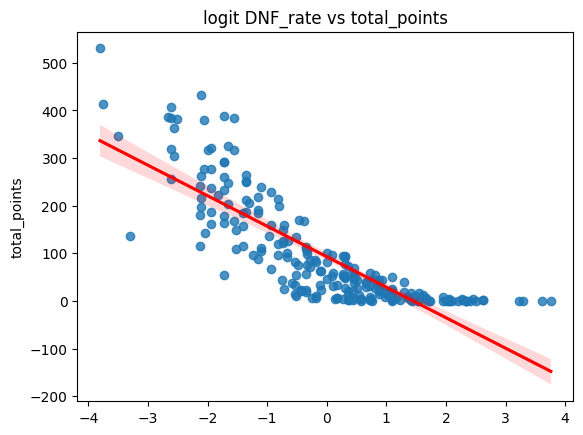

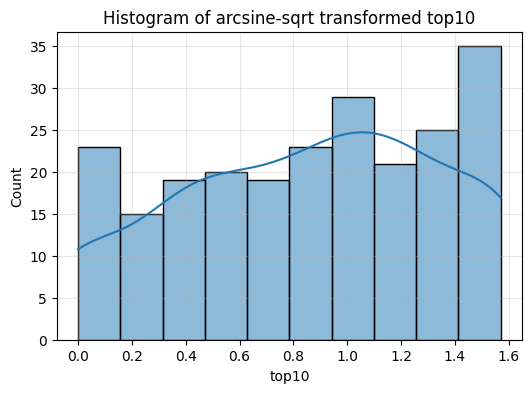

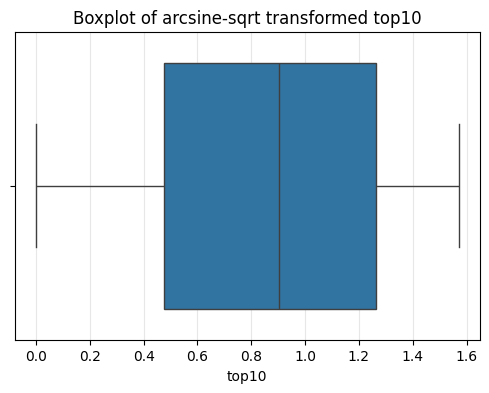

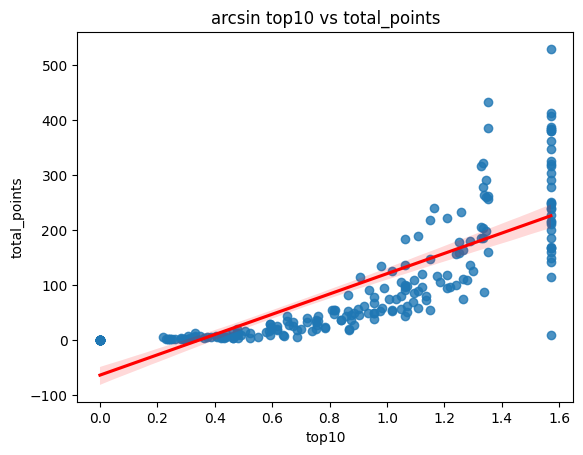

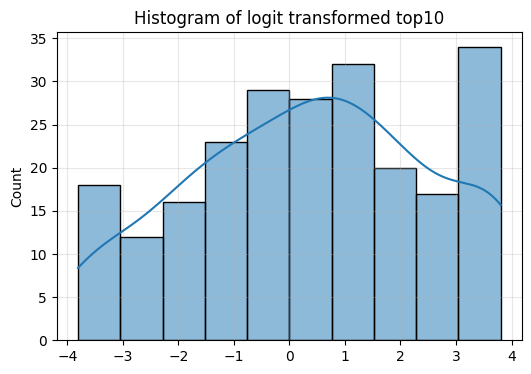

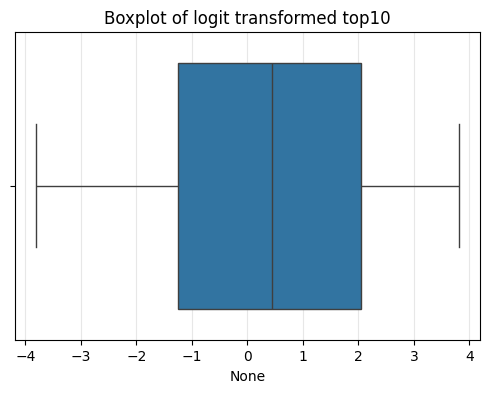

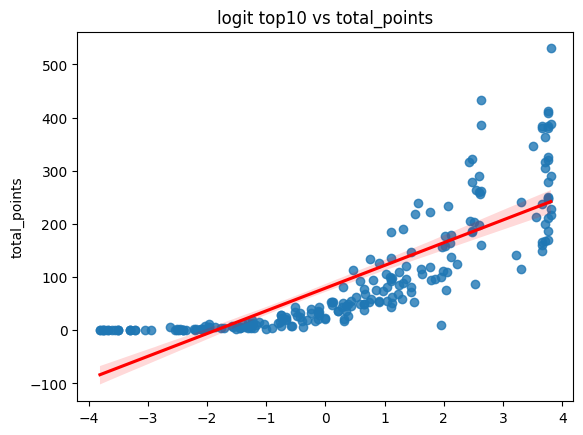

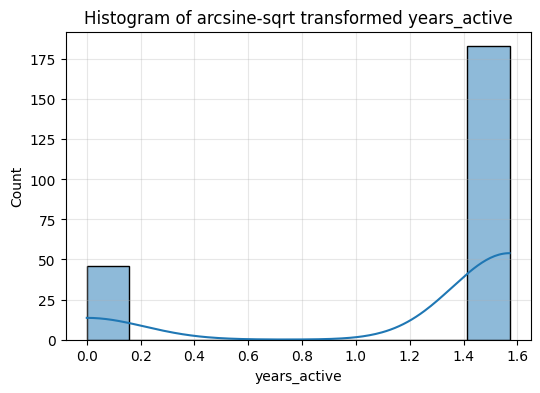

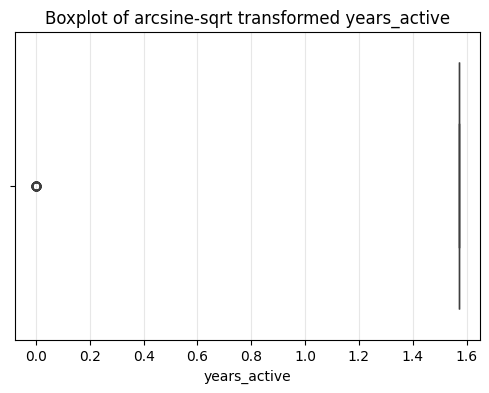

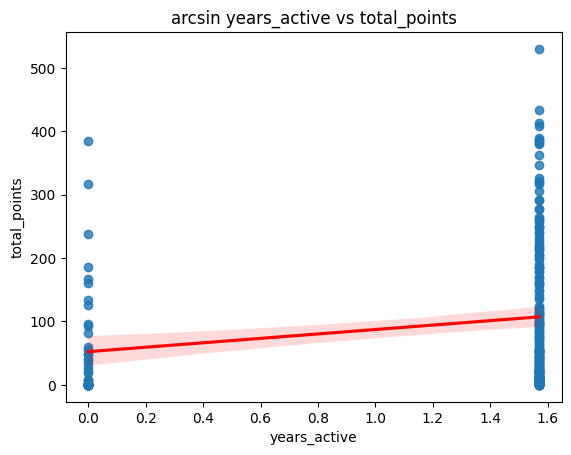

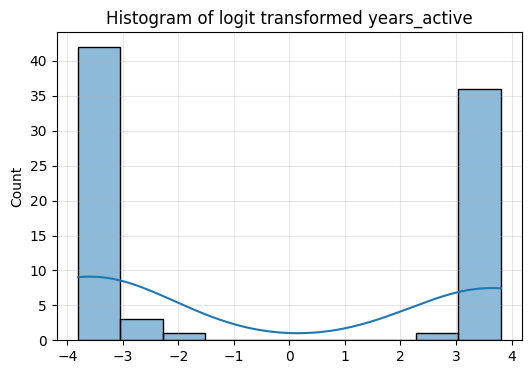

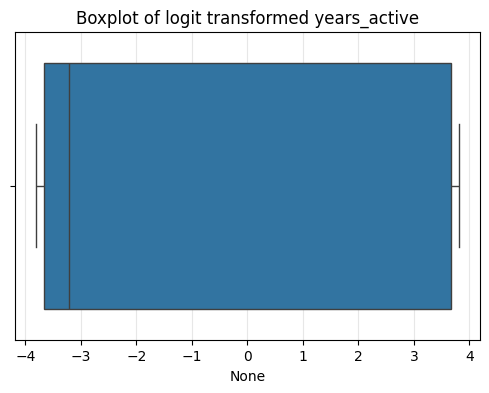

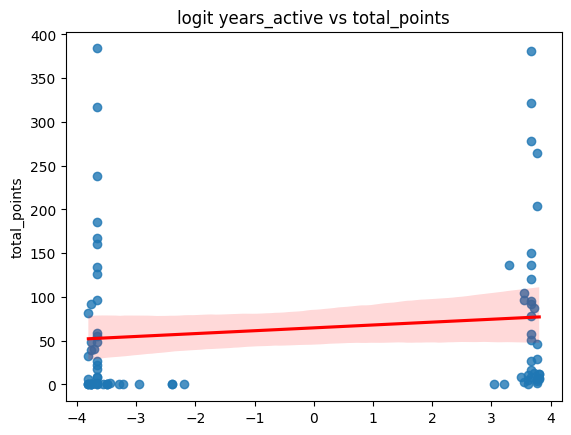

In [63]:
from scipy.special import logit as logit_trans

plot_df = df[["high_alt_sucess_rate", "DNF_rate", "top10", "years_active", "races_entered", "total_points"]].copy()
plot_df = plot_df.dropna(subset=["high_alt_sucess_rate", "DNF_rate", "top10", "years_active", "races_entered", "total_points"])

for var in ["high_alt_sucess_rate", "DNF_rate", "top10", "years_active"]:
    
    arcsin = np.arcsin(np.sqrt(plot_df[var]).clip(0, 1))
    p = (plot_df[var] * plot_df["races_entered"] + 0.5) / (plot_df["races_entered"] + 1)
    logit = logit_trans(p)
    
    # --- Arcsine Histogram ---
    plt.figure(figsize=(6,4))
    sns.histplot(arcsin, kde=True, bins=10)
    plt.title(f"Histogram of arcsine-sqrt transformed {var}")
    plt.grid(alpha=0.3)
    plt.savefig(f"images/{var}_arcsin_hist.png", dpi=150, bbox_inches="tight")
    plt.show()
    
    # --- Arcsine Boxplot ---
    plt.figure(figsize=(6,4))
    plt.title(f"Boxplot of arcsine-sqrt transformed {var}")
    plt.grid(True, alpha=0.3)
    sns.boxplot(x=arcsin)
    plt.savefig(f"images/{var}_arcsin_box.png", dpi=150, bbox_inches="tight")
    plt.show()
    
    # --- Arcsine Regression ---
    plt.figure()
    sns.regplot(x=arcsin, y=plot_df["total_points"], line_kws={"color": "red"})
    plt.title(f"arcsin {var} vs total_points")
    plt.savefig(f"images/{var}_arcsin_reg.png", dpi=150, bbox_inches="tight")
    plt.show()
    
    # --- Logit Histogram ---
    plt.figure(figsize=(6,4))
    sns.histplot(logit, kde=True, bins=10)
    plt.title(f"Histogram of logit transformed {var}")
    plt.grid(alpha=0.3)
    plt.savefig(f"images/{var}_logit_hist.png", dpi=150, bbox_inches="tight")
    plt.show()

    # --- Logit Boxplot ---
    plt.figure(figsize=(6,4))
    plt.title(f"Boxplot of logit transformed {var}")
    plt.grid(True, alpha=0.3)
    sns.boxplot(x=logit)
    plt.savefig(f"images/{var}_logit_box.png", dpi=150, bbox_inches="tight")
    plt.show()
    
    # --- Logit Regression ---
    plt.figure()
    sns.regplot(x=logit, y=plot_df["total_points"], line_kws={"color": "red"})
    plt.title(f"logit {var} vs total_points")
    plt.savefig(f"images/{var}_logit_reg.png", dpi=150, bbox_inches="tight")
    plt.show()
    
    print("\n")

The transformations primarily improved the distributions of top 10 rate and DNF rate, which originally had reasonably good distributions. This came at a slight cost of interpretability. The relationship with the response variable (total points) became more apparent — although not strictly linear, the transformed variables reveal a clear curved pattern that was harder to see in the raw proportions. Both arcsine-sqrt and logit transformations produced similar effects, with no obvious “winner” in terms of distribution normalization. However, because interpretability is important in practice, the logit transformation is preferred. Its values can be interpreted in terms of log-odds, which is often easier to explain and communicate than arcsine-sqrt units. 

For the remaining features, neither the logit nor the arcsine-sqrt transformations improved their distributions. In fact, some extreme values at the ends became even more pronounced. This indicates that these features have inherently nonlinear relationships with the response variable (total points), and applying linear transformations alone won’t make them suitable for a standard linear model. Therefore, to make effective use of these variables without “breaking” the model assumptions, a nonlinear modeling approach — such as decision trees, random forests, gradient boosting, or spline-based regression — will likely be necessary. These methods can capture complex, nonlinear patterns without requiring the predictors to be normally distributed or linearly related to the response.

It is important to note that for comput the logit transformation i added add 0.5 to the numerator when applying the logit to proportions to prevent infinities for values of 0 or 1, creating a small, safe adjustment that stabilizes the transformation without significantly altering the data.

In [64]:
dnf_p = (df["DNF_rate"] * df["races_entered"] + 0.5) / (df["races_entered"] + 1)
logit_dnf = logit_trans(dnf_p)

top10_p = (df["top10"] * df["races_entered"] + 0.5) / (df["races_entered"] + 1)
logit_top10 = logit_trans(top10_p)

df["logit_dnf"] = logit_dnf
df["logit_top10"] = logit_top10

print(f"Missing values:\n{df[['logit_dnf']].isna().sum()}\n{df[['logit_dnf']].isna().sum()}")

Missing values:
logit_dnf    0
dtype: int64
logit_dnf    0
dtype: int64


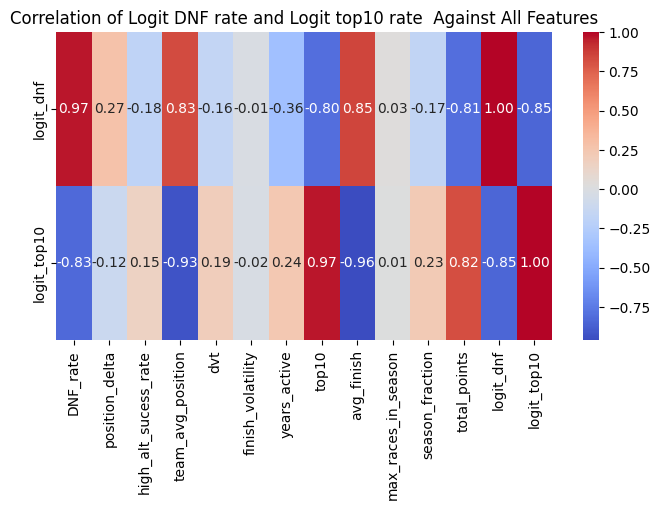

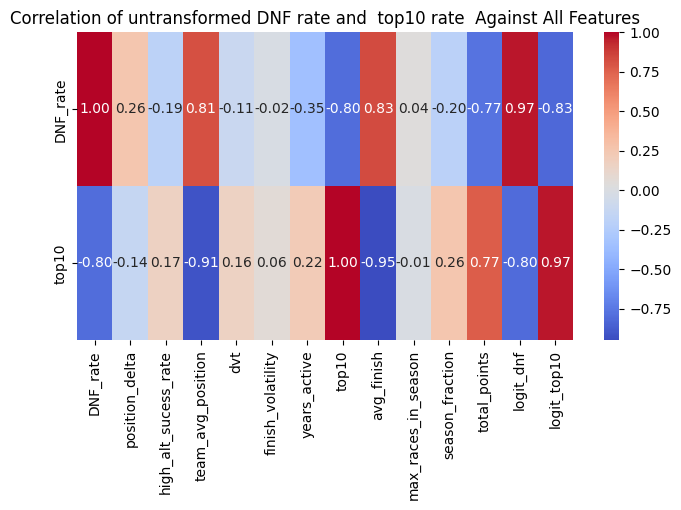

In [66]:
# Correlation function only takes numeric columns
numeric_df.drop(columns=["top10", "DNF_rate"]).select_dtypes(include="number")
numeric_df["logit_dnf"] = logit_dnf
numeric_df["logit_top10"] = logit_top10

corr_matrix = numeric_df.corr()  
corr_subset = corr_matrix.loc[["logit_dnf", "logit_top10"]]
corr_subset2 = corr_matrix.loc[["DNF_rate", "top10"]]


plt.figure(figsize=(8, 4))
sns.heatmap(corr_subset, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation of Logit DNF rate and Logit top10 rate  Against All Features")
plt.savefig(f"images/trans_correlations.png", dpi=150, bbox_inches="tight")

plt.show()


plt.figure(figsize=(8, 4))
sns.heatmap(corr_subset2, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation of untransformed DNF rate and  top10 rate  Against All Features")
plt.savefig(f"images/untrans_correlations.png", dpi=150, bbox_inches="tight")
plt.show()

Correlations haven't changed significantly, just a couple of tenths.

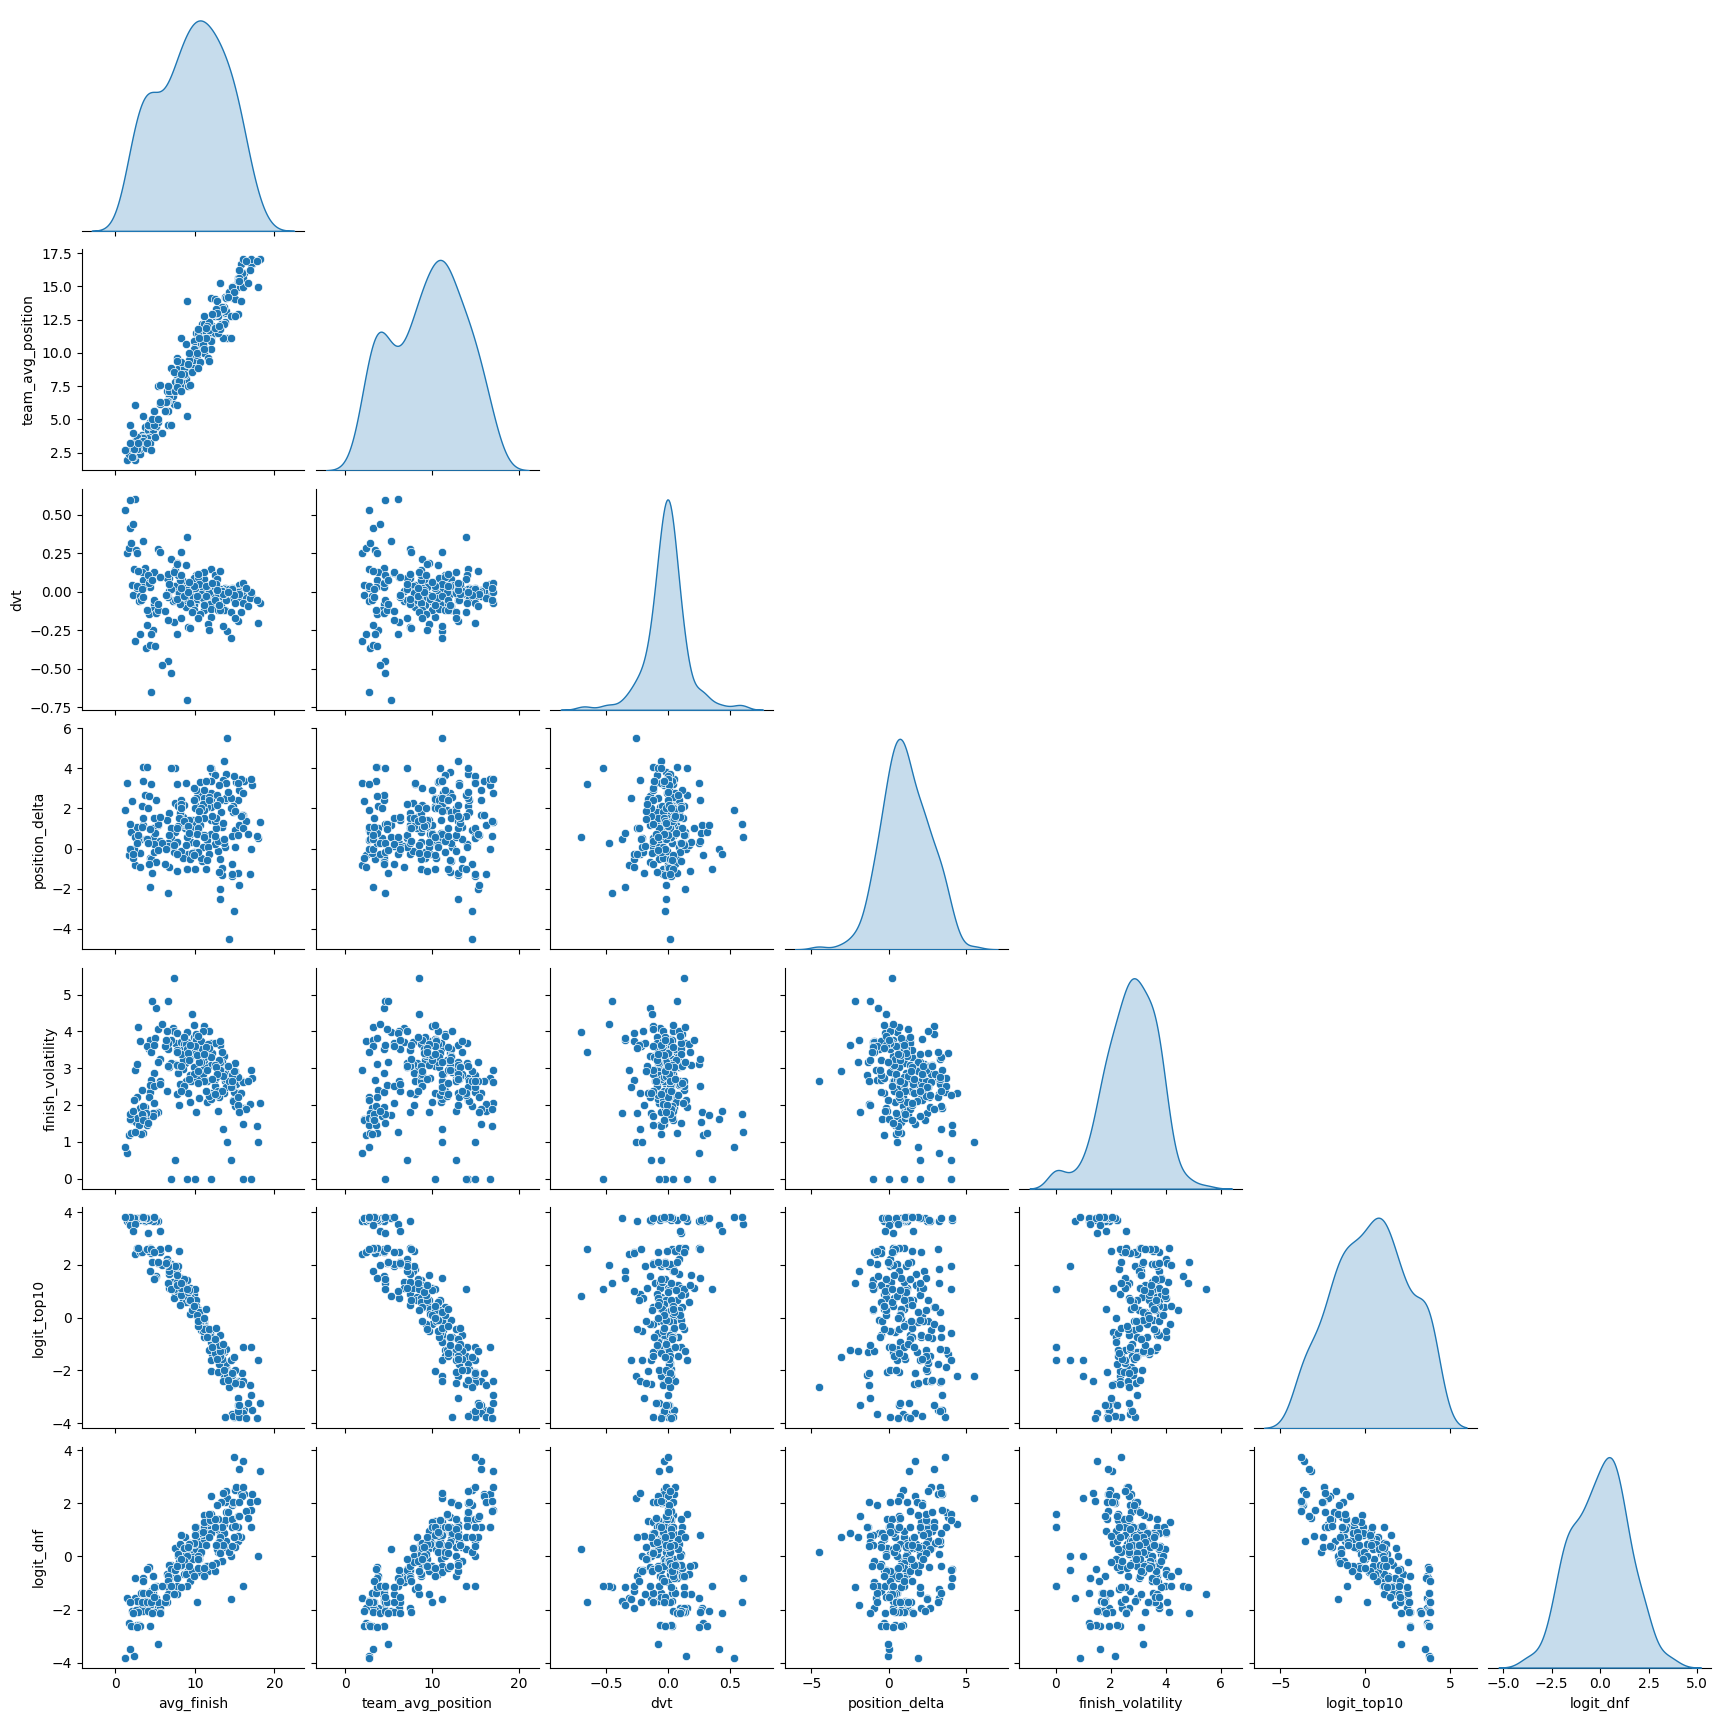

In [67]:
perf_features = [
    'avg_finish', 'team_avg_position',  'dvt', 'position_delta', 'finish_volatility', 'logit_top10', 'logit_dnf'
]

features = df[perf_features]

for cols in [perf_features]:
    sns.pairplot(
        features[cols],
        corner=True,         
        diag_kind="kde",     
    )
    plt.savefig(f"images/trans_pairplots.png", dpi=150, bbox_inches="tight")
    plt.show()

Some relationships are more linear now, although the difference once again is not very difference as before.

## Correlation and Redundancy Check

In [198]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df[perf_features].dropna()

vif = pd.DataFrame()
vif["feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif)

             feature         VIF
0         avg_finish  398.260962
1  team_avg_position  398.682189
2                dvt    4.465646
3     position_delta    1.831386
4  finish_volatility    8.934304
5        logit_top10    5.201406
6          logit_dnf    4.098667


In [201]:
perf_features.remove("team_avg_position")
X = df[perf_features].dropna()

vif = pd.DataFrame()
vif["feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif)

             feature        VIF
0         avg_finish  10.537474
1                dvt   1.081974
2     position_delta   1.815831
3  finish_volatility   8.663490
4        logit_top10   5.111979
5          logit_dnf   3.947808


After addressing severe multicollinearity by removing team_avg_position, the VIF diagnostics show a substantial improvement in model stability. The extreme redundancy (VIF ≈ 400) between avg_finish and team_avg_position has been eliminated, and all remaining predictors now fall within acceptable or borderline ranges. avg_finish (VIF ≈ 10.5) and finish_volatility (VIF ≈ 8.7) exhibit moderately high multicollinearity, which is expected given that performance metrics naturally overlap in meaning, but no longer pose a structural threat to model estimation. The remaining variables (logit_top10, logit_dnf, position_delta, and dvt) show acceptable VIF values, indicating stable and interpretable coefficient estimation. Overall, the feature set is now sufficiently well-conditioned to proceed to model fitting without major multicollinearity concerns.

## Missing values

In [203]:
df.isna().sum()

driverId                 0
year                     0
DNF_rate                 0
ref                      0
constructor              0
constructorRef           0
position_delta           4
high_alt_sucess_rate    14
team_avg_position        0
dvt                      4
finish_volatility        4
years_active             0
top10                    4
avg_finish               4
races_entered            0
max_races_in_season      0
season_fraction          0
total_points             0
fv_terciles              4
dvt_terciles             4
logit_dnf                0
logit_top10              4
dtype: int64

In [207]:
from sklearn.impute import SimpleImputer

num_cols = ["position_delta", "dvt", "finish_volatility", "top10",
            "avg_finish", "high_alt_sucess_rate", "logit_top10"]

num_imputer = SimpleImputer(strategy="median")
df[num_cols] = num_imputer.fit_transform(df[num_cols])

# Categorical / terciles columns to impute with mode
cat_cols = ["fv_terciles", "dvt_terciles"]
cat_imputer = SimpleImputer(strategy="most_frequent")
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

# Verify no missing values remain
print(df[num_cols + cat_cols].isna().sum())

position_delta          0
dvt                     0
finish_volatility       0
top10                   0
avg_finish              0
high_alt_sucess_rate    0
logit_top10             0
fv_terciles             0
dvt_terciles            0
dtype: int64


Some features in the dataset had missing values, including driver performance metrics like position_delta and avg_finish as well as tercile-based categorical features. To handle these, we applied median imputation for numeric variables, which is robust to outliers and preserves the central tendency of the data, and mode imputation for categorical/tercile features to maintain the most common category. This ensures that the dataset is complete and suitable for clustering and other exploratory analyses without introducing bias from extreme values or arbitrary fill-ins.

Overall, the exploratory data analysis has characterized the distributions, relationships, and redundancies among the driver- and team-oriented features. Key transformations, including logit and arcsine-square-root, were applied to normalize proportion-based metrics like DNF rate and top-10 rate, enhancing interpretability and revealing clearer patterns with respect to performance. Correlation and VIF analyses highlighted potential multicollinearity, allowing us to identify which features provide unique information versus those that may be redundant. Missing values were carefully handled through median and mode imputation, ensuring a complete dataset without introducing bias or distortion.

With this clean and transformed dataset, we are now prepared to apply unsupervised techniques such as clustering and principal component analysis (PCA) in a separate notebook. These methods will allow us to uncover natural groupings of drivers and seasons, explore latent dimensions of performance, and identify patterns across teams and experience levels—all without relying on target variables. Together, the EDA provides a solid foundation for interpretable, data-driven insights into driver performance and sets the stage for further analytical exploration.

In [213]:
df.to_csv('modeling_tables/clustering.csv')